# F1 — Driver Career & Milestones (1950–2024)

Driver-focused analyses across the full history of F1.
This notebook covers **Section 2** of `QuestionsF1.txt`.

## Questions covered

| # | Question |
|---|---|
| 2.1  | Top 10 drivers — most career race starts |
| 2.2  | Drivers who finished every race of a season (100% completion) |
| 2.3  | Top 10 drivers — most DNFs + most common retirement reason |
| 2.4  | Drivers who competed for the most different teams |
| 2.5  | Drivers who raced across the most decades |
| 2.6  | Drivers who raced across the most eras |
| 2.7  | Longest gap: first → last win |
| 2.8  | Longest gap: first → last race |
| 2.9  | Drivers who never won a race |
| 2.10 | Drivers who never scored a podium |
| 2.11 | Drivers who never finished in the top 10 |
| 2.12 | Youngest & oldest at three milestones (pole / podium / win) |
| 2.13 | Youngest & oldest race participants, split at year 2000 |
| 2.14 | Drivers who scored points on debut race |
| 2.15 | Drivers who scored a podium in their debut season |
| 2.16 | Drivers who won a race in their debut season |
| 2.17a | Surnames shared by >= 2 drivers - top 15 (Family vs unrelated namesakes) |
| 2.17b | Most recent F1 families - top 15 family surnames by latest driver activity |

**Sidebars** — Early F1 era (1950–1960): full 1950 season + top 15 drivers, plus a 'best debut RACE / best ROOKIE championship' ranking that complements 2.14–2.16.

## Setup — imports and data loading

In [331]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from f1_utils import (
    show_and_save, eras_df, year_to_era, apply_default_style,
)
apply_default_style()

sns.set_theme(style='whitegrid')

drivers      = pd.read_csv('excel/drivers.csv')
results      = pd.read_csv('excel/results.csv')
races        = pd.read_csv('excel/races.csv')
constructors = pd.read_csv('excel/constructors.csv')
circuits     = pd.read_csv('excel/circuits.csv')
qualifying   = pd.read_csv('excel/qualifying.csv')
standings    = pd.read_csv('excel/driver_standings.csv')

print('drivers     :', drivers.shape)
print('results     :', results.shape)
print('races       :', races.shape)
print('constructors:', constructors.shape)
print('circuits    :', circuits.shape)
print('qualifying  :', qualifying.shape)
print('standings   :', standings.shape)

drivers     : (861, 9)
results     : (26759, 18)
races       : (1125, 18)
constructors: (212, 5)
circuits    : (77, 9)
qualifying  : (10494, 9)
standings   : (34863, 7)


## Data cleanup — Indianapolis 500 (1950–1960)

The Indy 500 was nominally part of the F1 World Championship from **1950 to 1960** but was a separate American oval race. Most "F1 drivers" appearing in those rows never raced anywhere else in F1, which pollutes per-driver statistics (drivers who never won, youngest pole sitter, best debut, etc.).

We strip these entries **once at the source** so every downstream analysis is clean. This is the kind of data quality decision a real analyst makes — the rules of the championship and the *sport* aren't the same thing.

In [332]:
# Identify Indy 500 races and drop them from results, qualifying, races
indy_race_ids = races.loc[
    races['name'].str.contains('Indianapolis', case=False, na=False),
    'raceId'
]

n_before_results = len(results)

results    = results   [~results   ['raceId'].isin(indy_race_ids)].copy()
qualifying = qualifying[~qualifying['raceId'].isin(indy_race_ids)].copy()
races      = races     [~races     ['raceId'].isin(indy_race_ids)].copy()

print(f'Indy 500 races removed   : {len(indy_race_ids)}')
print(f'Result rows dropped      : {n_before_results - len(results):,}')
print(f'Clean dataset:')
print(f'  races      : {len(races):,}')
print(f'  results    : {len(results):,}')
print(f'  qualifying : {len(qualifying):,}')

Indy 500 races removed   : 11
Result rows dropped      : 405
Clean dataset:
  races      : 1,114
  results    : 26,354
  qualifying : 10,494


## SQL setup — in-memory SQLite database

The `Chart 2.1b` / `2.1c` cells and the Driver Explorer above run pure-SQL queries against an in-memory SQLite database loaded with the same dataframes used everywhere else in this notebook. This lets us show the SQL-equivalent answer alongside the pandas one.


In [333]:
import sqlite3

conn = sqlite3.connect(':memory:')
drivers.to_sql('drivers',      conn, if_exists='replace', index=False)
results.to_sql('results',      conn, if_exists='replace', index=False)
races.to_sql('races',          conn, if_exists='replace', index=False)
constructors.to_sql('constructors', conn, if_exists='replace', index=False)
circuits.to_sql('circuits',    conn, if_exists='replace', index=False)
standings.to_sql('standings',  conn, if_exists='replace', index=False)
print('SQLite tables loaded: drivers, results, races, constructors, circuits, standings')


SQLite tables loaded: drivers, results, races, constructors, circuits, standings


---
# 1. Driver Career & Milestones

## Driver Explorer — per-season breakdown for any driver

Set `SURNAME` (and optionally `FORENAME` to disambiguate) at the top of the cell — works for any driver in the dataset, e.g. `('Hamilton', 'Lewis')`, `('Verstappen', 'Max')`, `('Schumacher', 'Michael')`, `('Senna', 'Ayrton')`, `('Alonso', 'Fernando')`. The cell builds a per-season summary — races, wins, podiums, total points — and plots wins-by-year and points-by-year side by side.

**Inactive seasons (zero races) are filtered out** before plotting, so a driver who took a sabbatical doesn't show a misleading dip to zero on the chart.

> Surnames are not unique (104 drivers in the dataset share one). When you leave `FORENAME = None` and more than one driver matches, the cell lists the candidates instead of plotting.


Max Verstappen — per-season summary:
 year  races  wins  podiums  total_points
 2015     19     0        0          49.0
 2016     21     1        7         204.0
 2017     20     2        4         168.0
 2018     21     2       11         249.0
 2019     21     3        9         278.0
 2020     17     2       11         214.0
 2021     22    10       18         388.5
 2022     22    15       17         433.0
 2023     22    19       21         530.0
 2024     24     9       14         399.0


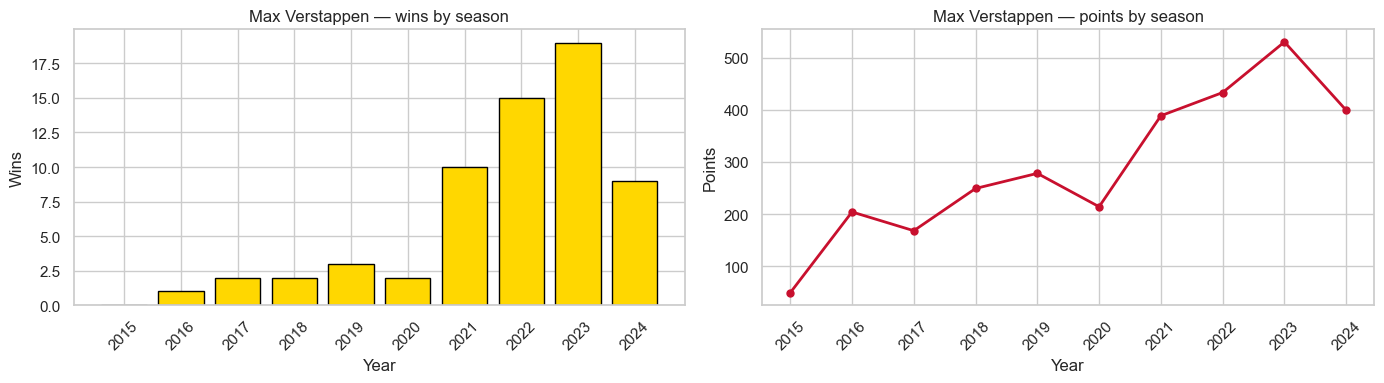

In [334]:
# Change this to look up any driver. SURNAME is required; FORENAME is
# optional and disambiguates when multiple drivers share a surname
# (e.g. Lewis Hamilton vs. Duncan Hamilton from the 1950s).
SURNAME  = 'Verstappen'
FORENAME = 'Max'      # set to None to see every driver with that surname

# Step 1 — resolve to a single driverId. If multiple match, list them and stop.
if FORENAME:
    matches = drivers[(drivers['surname'] == SURNAME) &
                      (drivers['forename'] == FORENAME)]
else:
    matches = drivers[drivers['surname'] == SURNAME]

if matches.empty:
    print(f'No driver found for surname={SURNAME!r}, forename={FORENAME!r}.')
elif len(matches) > 1:
    print(f'Multiple drivers share surname {SURNAME!r}. Set FORENAME to one of:')
    print(matches[['forename', 'surname', 'nationality', 'dob']].to_string(index=False))
else:
    driver_id = int(matches['driverId'].iloc[0])
    full_name = f"{matches['forename'].iloc[0]} {matches['surname'].iloc[0]}"

    # Step 2 — per-season summary, inactive years dropped via HAVING races > 0
    query_explorer = f"""
    SELECT
        ra.year,
        COUNT(*) AS races,
        SUM(CASE WHEN r.positionOrder = 1 THEN 1 ELSE 0 END) AS wins,
        SUM(CASE WHEN r.positionOrder <= 3 THEN 1 ELSE 0 END) AS podiums,
        SUM(r.points) AS total_points
    FROM   results r
    JOIN   races   ra ON r.raceId = ra.raceId
    WHERE  r.driverId = {driver_id}
    GROUP  BY ra.year
    HAVING races > 0
    ORDER  BY ra.year
    """

    df_driver = pd.read_sql(query_explorer, conn)
    print(f'{full_name} — per-season summary:')
    print(df_driver.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(df_driver['year'], df_driver['wins'], color='gold', edgecolor='black')
    axes[0].set_title(f'{full_name} — wins by season')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Wins')

    axes[1].plot(df_driver['year'], df_driver['total_points'],
                 color='#c8102e', marker='o', markersize=5, linewidth=2)
    axes[1].set_title(f'{full_name} — points by season')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Points')

    # Integer year ticks on both panels (one tick per actual season).
    for ax in axes:
        ax.set_xticks(df_driver['year'])
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    slug = SURNAME.lower()
    show_and_save(f'driver_explorer_{slug}.png')


## Section 2 — Career-volume questions (Q2.1 – Q2.8)

These eight questions all measure the *shape* of a driver's career rather than peak performance: how many races, how many DNFs, how many teams, how many decades and eras they spanned, and how wide the gaps between their firsts and lasts run.

| # | Question |
|---|---|
| 2.1 | Top 10 drivers — most career race starts |
| 2.2 | Drivers who finished every race of a season (100% completion) |
| 2.3 | Top 10 drivers — most DNFs + most common retirement reason |
| 2.4 | Drivers who competed for the most different teams |
| 2.5 | Drivers who raced across the most decades |
| 2.6 | Drivers who raced across the most eras |
| 2.7 | Longest gap between first and last win |
| 2.8 | Longest gap between first and last race |

The `status` lookup table is required for **2.2** (was the result a finish?) and **2.3** (which retirement reason?). The file lives at `excel/status.csv` — we load it once here so every chart below can reuse it.


In [335]:
# Load the status lookup table — maps statusId → human-readable status string.
# 'Finished' = statusId 1; '+N Lap(s)' rows are also classified finishes
# (the driver completed the race but a few laps down). Everything else is a DNF.
status = pd.read_csv('excel/status.csv')

# Build the set of statusIds that count as a CLASSIFIED finish.
finished_status = status[(status['status'] == 'Finished') |
                         status['status'].str.startswith('+')]
finished_status_ids = set(finished_status['statusId'])

print(f'Status rows         : {len(status)}')
print(f'Classified-finish ids: {sorted(finished_status_ids)}')

# A driver-result is a DNF if its statusId is NOT in finished_status_ids.
# Disqualifications (statusId == 2) are TREATED AS DNF here because the result
# was wiped — that's the most common convention in F1 stat sites.
results['is_finish'] = results['statusId'].isin(finished_status_ids)


# Per-decade bar palette. Defined here (early in the notebook) so every chart
# in section 2 can use the same hue for a driver's debut decade. Q1 / Q5 below
# *redefine* the same dict — that's intentional, the cells stay self-contained.
DECADE_COLORS = {
    1950: '#8B2635',  # burgundy
    1960: '#D2691E',  # chocolate orange
    1970: '#DAA520',  # goldenrod
    1980: '#2E8B57',  # sea green
    1990: '#0E7C7B',  # teal
    2000: '#1F4E79',  # navy blue
    2010: '#5B2A86',  # royal purple
    2020: '#3A3A3A',  # dark gray
}


Status rows         : 139
Classified-finish ids: [1, 11, 12, 13, 14, 15, 16, 17, 18, 19, 45, 50, 53, 55, 58, 88, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 122, 123, 124, 125, 127, 128, 133, 134]


### Chart 2.0 — F1 Drivers Funnel (1950–2024)

Sets the stage for everything in Section 2: of every driver who ever entered an F1 race, how many cleared each performance bar at least once?


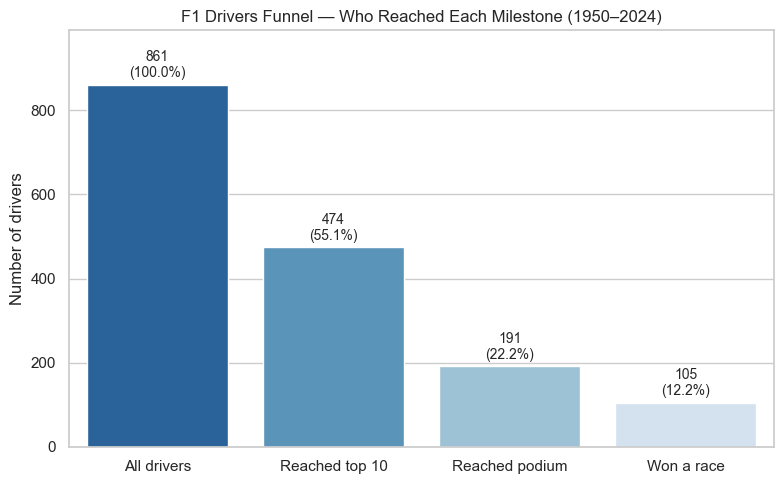

In [336]:
# Step 1 — sets of driverIds who reached each milestone at least once
winner_ids = set(results.loc[results['positionOrder'] == 1, 'driverId'])
podium_ids = set(results.loc[results['positionOrder'] <= 3, 'driverId'])
top10_ids  = set(results.loc[results['positionOrder'] <= 10, 'driverId'])

all_ids = set(drivers['driverId'])
total = len(all_ids)

# Step 2 — funnel data + chart (vertical)
funnel = pd.DataFrame({
    'category': ['All drivers', 'Reached top 10', 'Reached podium', 'Won a race'],
    'count':    [total, len(top10_ids), len(podium_ids), len(winner_ids)]
})
funnel['pct'] = funnel['count'] / total * 100

plt.figure(figsize=(8, 5))
sns.barplot(data=funnel, x='category', y='count',
            hue='category', palette='Blues_r', legend=False)
for i, row in enumerate(funnel.itertuples()):
    plt.text(i, row.count + total * 0.02,
             f'{row.count}\n({row.pct:.1f}%)',
             ha='center', fontsize=10)
plt.title('F1 Drivers Funnel — Who Reached Each Milestone (1950–2024)')
plt.xlabel('')
plt.ylabel('Number of drivers')
plt.ylim(0, total * 1.15)
plt.tight_layout()
show_and_save('2.0_funnel.png')

**SQL equivalent**
```sql
-- Q1: Drivers funnel — counts at each milestone (Indy excluded)
SELECT 'All drivers'    AS milestone, COUNT(*) AS n_drivers FROM drivers
UNION ALL
SELECT 'Reached top 10', COUNT(DISTINCT r.driverId)
FROM   results r JOIN races ra ON r.raceId = ra.raceId
WHERE  r.positionOrder <= 10 AND ra.name NOT LIKE '%Indianapolis%'
UNION ALL
SELECT 'Reached podium', COUNT(DISTINCT r.driverId)
FROM   results r JOIN races ra ON r.raceId = ra.raceId
WHERE  r.positionOrder <= 3  AND ra.name NOT LIKE '%Indianapolis%'
UNION ALL
SELECT 'Won a race',     COUNT(DISTINCT r.driverId)
FROM   results r JOIN races ra ON r.raceId = ra.raceId
WHERE  r.positionOrder =  1  AND ra.name NOT LIKE '%Indianapolis%';
```

### Chart 2.1 — Top 10 drivers, most career race starts

A **race start** = one row in `results` where the driver actually appeared at the GP. Indy 500 is excluded (cleaned up at the source). No filter on finish status — a DNF still counts as a start, because the driver lined up on the grid.

This is the simplest longevity metric and a useful baseline for the per-driver counts that follow: divide DNFs (2.3) or team count (2.4) by starts to get rates that are comparable across eras.


Top 10 drivers by career race starts:
        driver  starts  first_year
     Alonso F.     404        2001
   Hamilton L.     356        2007
  Räikkönen K.     352        2001
Barrichello R.     326        1993
     Button J.     309        2000
 Schumacher M.     308        1991
     Vettel S.     300        2007
      Pérez S.     283        2011
      Massa F.     271        2002
    Patrese R.     257        1977


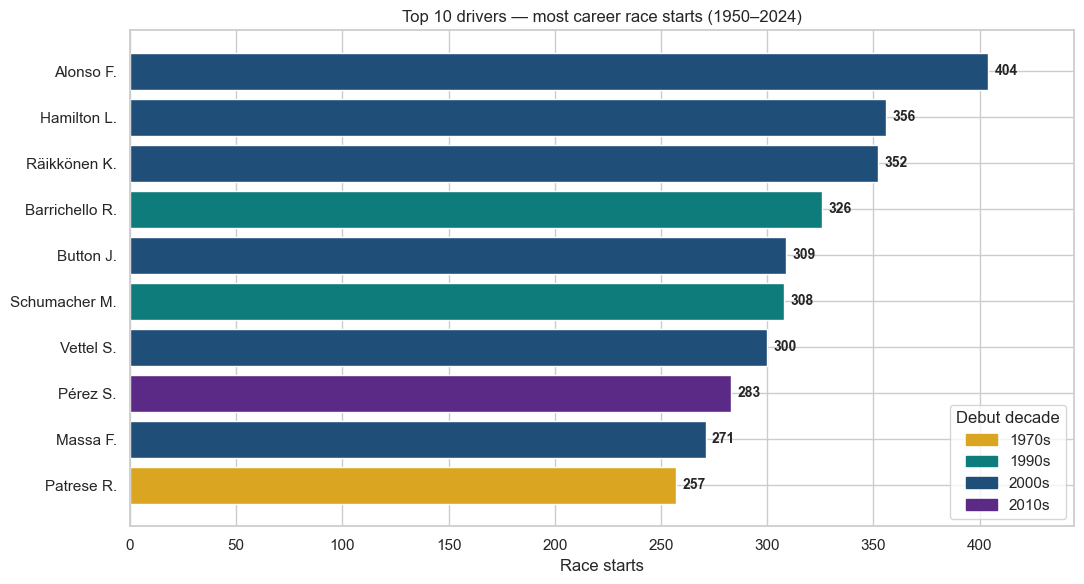

In [337]:
starts_per_driver = (
    results.groupby('driverId').size()
    .reset_index(name='starts')
    .merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
)
starts_per_driver['driver'] = starts_per_driver['surname'] + ' ' + starts_per_driver['forename'].str[0] + '.'

# Each driver's debut decade — used for consistent bar coloring across charts
first_year_per_driver = (
    results.merge(races[['raceId', 'year']], on='raceId')
    .groupby('driverId')['year'].min()
    .reset_index(name='first_year')
)
starts_per_driver = starts_per_driver.merge(first_year_per_driver, on='driverId')
starts_per_driver['decade'] = (starts_per_driver['first_year'] // 10) * 10

top10_starts = (starts_per_driver
                .sort_values('starts', ascending=False)
                .head(10)
                .sort_values('starts'))   # asc → biggest at top after barh

print('Top 10 drivers by career race starts:')
print(top10_starts[['driver', 'starts', 'first_year']]
      .sort_values('starts', ascending=False).to_string(index=False))

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in top10_starts['decade']]
plt.barh(range(len(top10_starts)), top10_starts['starts'], color=bar_colors)
plt.yticks(range(len(top10_starts)), top10_starts['driver'])

for i, row in enumerate(top10_starts.itertuples()):
    plt.text(row.starts + 3, i, str(row.starts),
             va='center', fontsize=10, fontweight='bold')

used = sorted(top10_starts['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade', loc='lower right', frameon=True)

plt.title('Top 10 drivers — most career race starts (1950–2024)')
plt.xlabel('Race starts')
plt.ylabel('')
plt.xlim(0, top10_starts['starts'].max() * 1.10)
plt.tight_layout()
show_and_save('2.1_most_starts.png')


**SQL equivalent**
```sql
-- 2.1: Top 10 drivers by career race starts (Indy 500 excluded)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    COUNT(*) AS starts,
    MIN(ra.year) AS first_year
FROM   results r
JOIN   races   ra ON r.raceId   = ra.raceId
JOIN   drivers d  ON r.driverId = d.driverId
WHERE  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY r.driverId
ORDER  BY starts DESC
LIMIT  10;
```


### Chart 2.1b — Top 10 drivers, most career race wins

Same top-10 lens as 2.1 but counting **wins** (positionOrder = 1) instead of starts. Indy 500 is already excluded at the source. Implemented in pure SQL against the in-memory SQLite database built in the setup section.


Top 10 drivers by career wins:
       driver nationality  wins
  Hamilton L.     British   105
Schumacher M.      German    91
Verstappen M.       Dutch    63
    Vettel S.      German    53
     Prost A.      French    51
     Senna A.   Brazilian    41
    Alonso F.     Spanish    32
   Mansell N.     British    31
   Stewart J.     British    27
     Clark J.     British    25


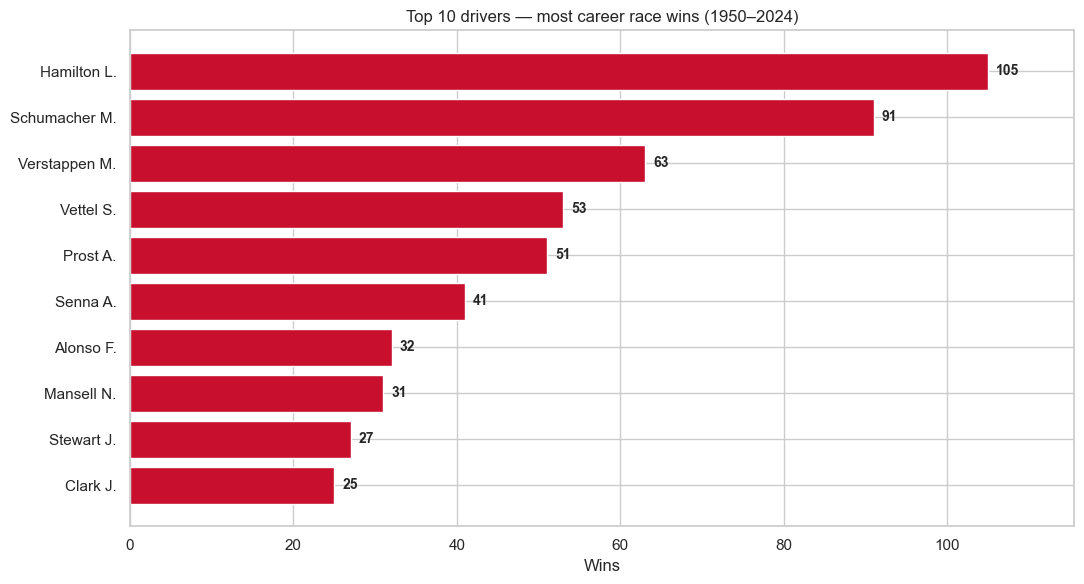

In [338]:
query_21b = """
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    d.nationality,
    COUNT(*) AS wins
FROM   results r
JOIN   drivers d ON r.driverId = d.driverId
WHERE  r.positionOrder = 1
GROUP  BY d.driverId
ORDER  BY wins DESC
LIMIT  10
"""

top10_wins = pd.read_sql(query_21b, conn)
print('Top 10 drivers by career wins:')
print(top10_wins.to_string(index=False))

plot_df = top10_wins.sort_values('wins')   # asc → biggest at top after barh

plt.figure(figsize=(11, 6))
plt.barh(range(len(plot_df)), plot_df['wins'], color='#c8102e')
plt.yticks(range(len(plot_df)), plot_df['driver'])

for i, row in enumerate(plot_df.itertuples()):
    plt.text(row.wins + 1, i, str(row.wins),
             va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 drivers — most career race wins (1950–2024)')
plt.xlabel('Wins')
plt.xlim(0, plot_df['wins'].max() * 1.10)
plt.tight_layout()
show_and_save('2.1b_most_wins.png')


### Chart 2.1c — Career volume + average finishing position (drivers with 100+ starts)

Combines the three career-volume metrics — **starts**, **wins**, **average finishing position** — for every driver with at least 100 race starts, sorted by wins. Average finish over 100+ starts is the closest single number to "how consistently good was this driver across their career."


In [339]:
query_21c = """
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    COUNT(*) AS starts,
    SUM(CASE WHEN r.positionOrder = 1 THEN 1 ELSE 0 END) AS wins,
    ROUND(AVG(r.positionOrder), 1) AS avg_finish
FROM   results r
JOIN   drivers d ON r.driverId = d.driverId
GROUP  BY d.driverId
HAVING starts >= 100
ORDER  BY wins DESC
LIMIT  15
"""

career_volume = pd.read_sql(query_21c, conn)
print('Top 15 drivers (100+ starts) by career wins, with average finish:')
print(career_volume.to_string(index=False))


Top 15 drivers (100+ starts) by career wins, with average finish:
       driver  starts  wins  avg_finish
  Hamilton L.     356   105         5.0
Schumacher M.     308    91         6.9
Verstappen M.     209    63         5.6
    Vettel S.     300    53         7.1
     Prost A.     202    51         7.5
     Senna A.     162    41         8.3
    Alonso F.     404    32         8.5
   Mansell N.     192    31        11.2
   Stewart J.     100    27         7.4
     Lauda N.     174    25        10.9
    Piquet N.     207    23        10.0
   Rosberg N.     206    23         8.3
      Hill D.     122    22         9.9
 Räikkönen K.     352    21         8.5
  Häkkinen M.     165    20         9.9


### Chart 2.2 — Drivers who finished every race of a season (100% completion)

A "100% season" means the driver:
1. **Started every race** that year (no skipped GPs), AND
2. **Was classified at the finish** in every one of them (no DNFs).

This is much rarer than just "scoring points every race" — early F1 had reliability issues, modern F1 has more races per season (24 in 2024 vs 6 in 1950). One bad clutch ends the streak.

Output as a **table** rather than a bar chart — the most-recent decades will dominate any aggregate view, and the actual driver-year combinations are interesting in their own right.


Driver-seasons with 100% start AND finish completion: 16

 year         driver  races
 1953    Hawthorn M.      8
 1954      Fangio J.      8
 1959 Trintignant M.      8
 1961      Gurney D.      8
 1964     Ginther R.     10
 2002  Schumacher M.     17
 2008    Heidfeld N.     18
 2012   Räikkönen K.     20
 2013     Chilton M.     19
 2016   Ricciardo D.     21
 2017    Hamilton L.     20
 2019    Hamilton L.     21
 2021       Sainz C.     22
 2023  Verstappen M.     22
 2024      Norris L.     24
 2024     Piastri O.     24


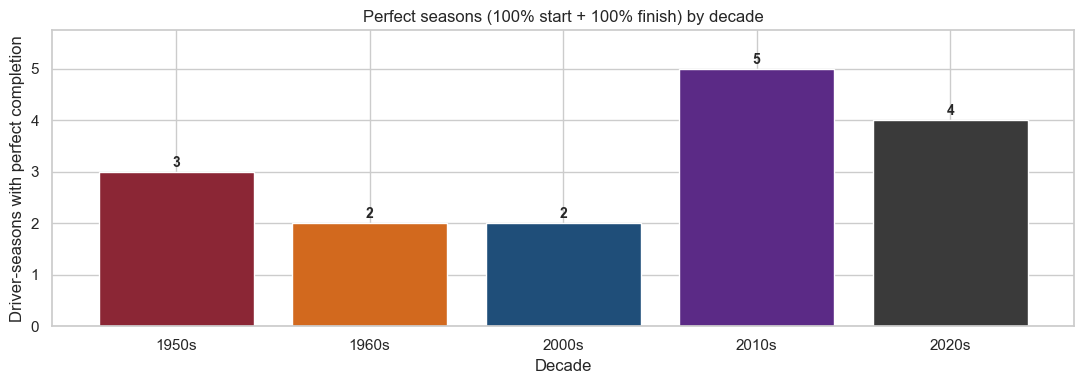

In [340]:
# Step 1 — number of races per season (the target)
season_size = races.groupby('year').size().reset_index(name='season_races')

# Step 2 — per (driver, year): starts and classified finishes
driver_year = (
    results.merge(races[['raceId', 'year']], on='raceId')
    .groupby(['driverId', 'year'])
    .agg(starts=('raceId', 'count'),
         finishes=('is_finish', 'sum'))
    .reset_index()
    .merge(season_size, on='year')
)

# Step 3 — perfect = started AND finished every race of the season
perfect = (driver_year[(driver_year['starts']   == driver_year['season_races']) &
                       (driver_year['finishes'] == driver_year['season_races'])]
           .merge(drivers[['driverId', 'forename', 'surname']], on='driverId'))
perfect['driver'] = perfect['surname'] + ' ' + perfect['forename'].str[0] + '.'
perfect = (perfect[['year', 'driver', 'starts']]
           .rename(columns={'starts': 'races'})
           .sort_values(['year', 'driver']))

print(f'Driver-seasons with 100% start AND finish completion: {len(perfect)}')
print()
print(perfect.to_string(index=False))

# Aggregate per decade — how often does a perfect season happen?
perfect['decade'] = (perfect['year'] // 10) * 10
per_decade = (perfect.groupby('decade').size()
              .reset_index(name='perfect_seasons'))

plt.figure(figsize=(11, 4))
bar_colors = [DECADE_COLORS.get(d, '#999') for d in per_decade['decade']]
plt.bar(per_decade['decade'].astype(str) + 's', per_decade['perfect_seasons'],
        color=bar_colors, edgecolor='white')
for i, row in enumerate(per_decade.itertuples()):
    plt.text(i, row.perfect_seasons + 0.1, str(row.perfect_seasons),
             ha='center', fontsize=10, fontweight='bold')

plt.title('Perfect seasons (100% start + 100% finish) by decade')
plt.xlabel('Decade')
plt.ylabel('Driver-seasons with perfect completion')
plt.ylim(0, max(per_decade['perfect_seasons'].max() * 1.15, 1))
plt.tight_layout()
show_and_save('2.2_perfect_seasons.png')


**SQL equivalent**
```sql
-- 2.2: Driver-seasons with 100% start AND 100% classified-finish completion
WITH season_size AS (
    SELECT year, COUNT(*) AS season_races
    FROM   races
    WHERE  name NOT LIKE '%Indianapolis%'
    GROUP  BY year
),
driver_year AS (
    SELECT
        r.driverId, ra.year,
        COUNT(*) AS starts,
        SUM(CASE WHEN s.status = 'Finished' OR s.status LIKE '+%' THEN 1 ELSE 0 END) AS finishes
    FROM   results r
    JOIN   races   ra ON r.raceId   = ra.raceId
    JOIN   status  s  ON r.statusId = s.statusId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
    GROUP  BY r.driverId, ra.year
)
SELECT
    dy.year,
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    dy.starts AS races
FROM   driver_year dy
JOIN   season_size ss ON dy.year = ss.year
JOIN   drivers     d  ON dy.driverId = d.driverId
WHERE  dy.starts   = ss.season_races
  AND  dy.finishes = ss.season_races
ORDER  BY dy.year, driver;
```


### Chart 2.3 — Top 10 drivers, most DNFs + most common retirement reason

A DNF (Did Not Finish) = a result whose `statusId` is **not** in the classified-finish set we built above. Includes Engine, Accident, Collision, Gearbox, Hydraulics, Disqualified, etc.

Two views:
- **Bar chart** of the top 10 by total DNF count, decade-colored.
- **Companion table** showing each top driver's *most common* retirement reason — pure career-volume drivers (Patrese, de Cesaris) often have the most DNFs simply because they raced the most, so the reason is what makes the line interesting (engine vs accident vs collision).


Top 10 drivers by career DNFs:
        driver  dnfs  starts   dnf_pct      top_reason  top_reason_count
 de Cesaris A.   153     214 71.495327          Engine                32
    Patrese R.   145     257 56.420233          Engine                36
   Alboreto M.   124     215 57.674419          Engine                36
Barrichello R.   102     326 31.288344          Engine                16
    Mansell N.   101     192 52.604167          Engine                22
    Warwick D.   101     162 62.345679 Did not qualify                14
    Cheever E.    98     143 68.531469          Engine                22
     Berger G.    95     210 45.238095          Engine                19
    Laffite J.    94     180 52.222222          Engine                19
     Trulli J.    94     256 36.718750          Engine                17


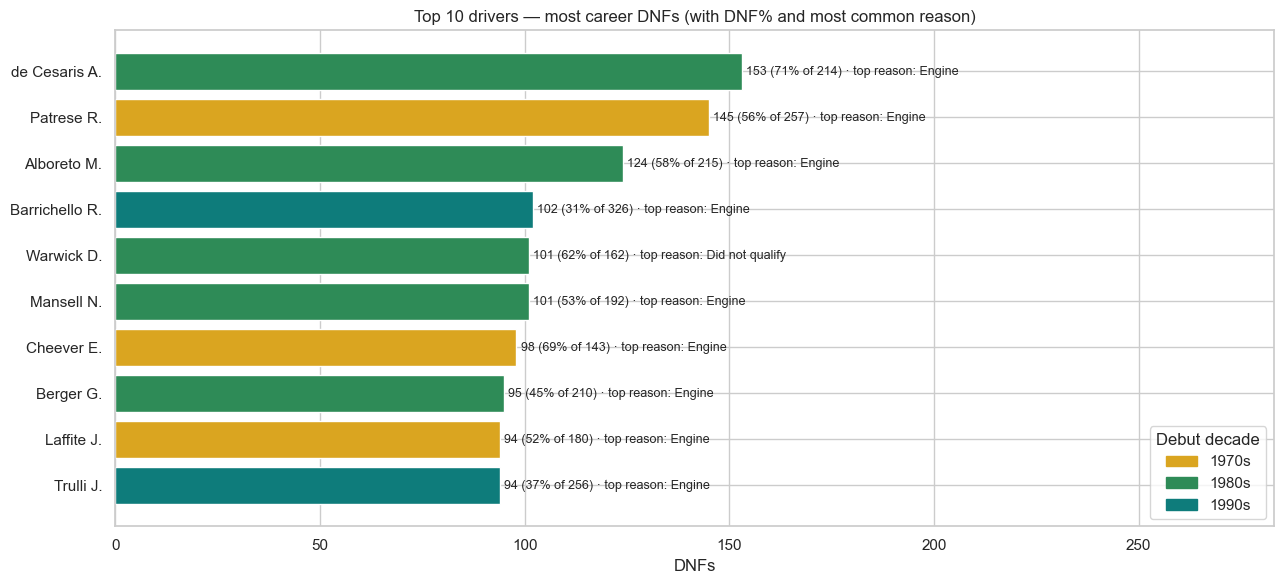

In [341]:
dnfs = (
    results[~results['is_finish']]
    .merge(status, on='statusId')
    .merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
)
dnfs['driver'] = dnfs['surname'] + ' ' + dnfs['forename'].str[0] + '.'

# Total DNFs per driver
dnf_counts = (dnfs.groupby('driverId').size()
              .reset_index(name='dnfs')
              .merge(starts_per_driver[['driverId', 'driver', 'starts', 'decade']],
                     on='driverId')
              .sort_values('dnfs', ascending=False))
dnf_counts['dnf_pct'] = dnf_counts['dnfs'] / dnf_counts['starts'] * 100

top10_dnfs = dnf_counts.head(10).sort_values('dnfs')

# Most common retirement reason per top-10 driver
top_reason = (dnfs[dnfs['driverId'].isin(top10_dnfs['driverId'])]
              .groupby(['driverId', 'status']).size()
              .reset_index(name='count')
              .sort_values(['driverId', 'count'], ascending=[True, False])
              .groupby('driverId').first()
              .reset_index()
              .rename(columns={'status': 'top_reason', 'count': 'top_reason_count'}))

top10_dnfs = top10_dnfs.merge(top_reason, on='driverId')

print('Top 10 drivers by career DNFs:')
print(top10_dnfs.sort_values('dnfs', ascending=False)
      [['driver', 'dnfs', 'starts', 'dnf_pct', 'top_reason', 'top_reason_count']]
      .to_string(index=False))

plt.figure(figsize=(13, 6))
bar_colors = [DECADE_COLORS[d] for d in top10_dnfs['decade']]
plt.barh(range(len(top10_dnfs)), top10_dnfs['dnfs'], color=bar_colors)
plt.yticks(range(len(top10_dnfs)), top10_dnfs['driver'])

for i, row in enumerate(top10_dnfs.itertuples()):
    plt.text(row.dnfs + 1, i,
             f'{row.dnfs} ({row.dnf_pct:.0f}% of {row.starts}) · top reason: {row.top_reason}',
             va='center', fontsize=9)

used = sorted(top10_dnfs['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade', loc='lower right', frameon=True)

plt.title('Top 10 drivers — most career DNFs (with DNF% and most common reason)')
plt.xlabel('DNFs')
plt.ylabel('')
plt.xlim(0, top10_dnfs['dnfs'].max() * 1.85)
plt.tight_layout()
show_and_save('2.3_most_dnfs.png')


**SQL equivalent**
```sql
-- 2.3a: Top 10 drivers by career DNFs (anything that wasn't a classified finish)
WITH dnfs AS (
    SELECT r.driverId, s.status
    FROM   results r
    JOIN   races   ra ON r.raceId   = ra.raceId
    JOIN   status  s  ON r.statusId = s.statusId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
      AND  s.status <> 'Finished'
      AND  s.status NOT LIKE '+%'             -- '+N Lap(s)' is still classified
)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    COUNT(*) AS dnfs
FROM   dnfs
JOIN   drivers d ON dnfs.driverId = d.driverId
GROUP  BY dnfs.driverId
ORDER  BY dnfs DESC
LIMIT  10;

-- 2.3b: Most common retirement reason per (top-10) driver
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    s.status AS reason,
    COUNT(*) AS reason_count
FROM   results r
JOIN   races   ra ON r.raceId   = ra.raceId
JOIN   status  s  ON r.statusId = s.statusId
JOIN   drivers d  ON r.driverId = d.driverId
WHERE  ra.name NOT LIKE '%Indianapolis%'
  AND  s.status <> 'Finished'
  AND  s.status NOT LIKE '+%'
  AND  r.driverId IN (/* top-10 driverIds from 2.3a */)
GROUP  BY r.driverId, s.status
QUALIFY ROW_NUMBER() OVER (PARTITION BY r.driverId ORDER BY COUNT(*) DESC) = 1;
```


### Chart 2.4 — Top 10 drivers who competed for the most different teams

`COUNT(DISTINCT constructorId)` per driver. The Ergast `constructors.csv` already deduplicates engine partnerships (e.g. 'Cooper-Climax' is one team, not 'Cooper' + 'Climax'), so the count is "team identities the driver wore at least once".

A high count usually means a long, journeyman career (Andrea de Cesaris drove for 10 different teams). It does *not* correlate with success — most of the multi-team drivers never won a championship.


Top 10 drivers by number of different teams:
        driver  teams  starts  first_year
       Amon C.     14     106        1963
Trintignant M.     13      87        1950
       Moss S.     12      73        1951
    Bonnier J.     12     109        1956
     Jarier J.     11     143        1971
  Johansson S.     10     103        1980
 de Cesaris A.     10     214        1980
     Gurney D.     10      87        1959
       Ickx J.     10     121        1967
  Salvadori R.     10      51        1952


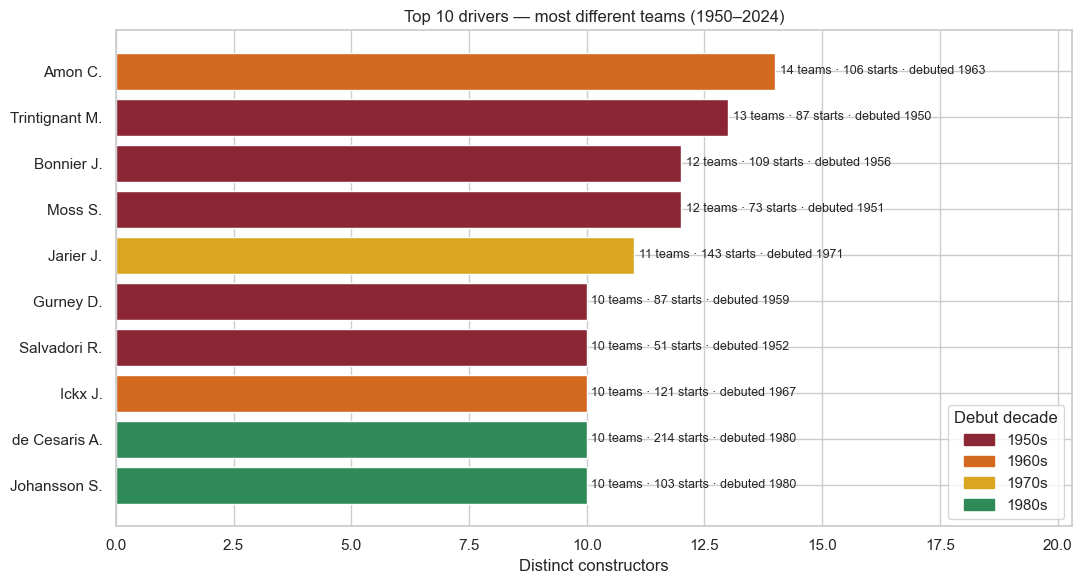

In [342]:
teams_per_driver = (
    results.groupby('driverId')['constructorId'].nunique()
    .reset_index(name='teams')
    .merge(starts_per_driver[['driverId', 'driver', 'starts', 'decade', 'first_year']],
           on='driverId')
    .sort_values('teams', ascending=False)
)

top10_teams = teams_per_driver.head(10).sort_values('teams')

print('Top 10 drivers by number of different teams:')
print(top10_teams.sort_values('teams', ascending=False)
      [['driver', 'teams', 'starts', 'first_year']].to_string(index=False))

plt.figure(figsize=(11, 6))
bar_colors = [DECADE_COLORS[d] for d in top10_teams['decade']]
plt.barh(range(len(top10_teams)), top10_teams['teams'], color=bar_colors)
plt.yticks(range(len(top10_teams)), top10_teams['driver'])

for i, row in enumerate(top10_teams.itertuples()):
    plt.text(row.teams + 0.1, i,
             f'{row.teams} teams · {row.starts} starts · debuted {int(row.first_year)}',
             va='center', fontsize=9)

used = sorted(top10_teams['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade', loc='lower right', frameon=True)

plt.title('Top 10 drivers — most different teams (1950–2024)')
plt.xlabel('Distinct constructors')
plt.ylabel('')
plt.xlim(0, top10_teams['teams'].max() * 1.45)
plt.tight_layout()
show_and_save('2.4_most_teams.png')


**SQL equivalent**
```sql
-- 2.4: Top 10 drivers by distinct constructors driven for
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    COUNT(DISTINCT r.constructorId) AS teams,
    COUNT(*)                        AS starts
FROM   results r
JOIN   races   ra ON r.raceId   = ra.raceId
JOIN   drivers d  ON r.driverId = d.driverId
WHERE  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY r.driverId
ORDER  BY teams DESC
LIMIT  10;
```


### Chart 2.5 — Drivers who raced across the most decades

Decade = `year // 10 * 10`. So a driver who raced 1999 and 2001 spans **two decades** (1990s and 2000s) even though only ~2 calendar years elapsed. This is the cheap version of question 2.6 — eras need explicit boundaries; decades just bucket by 10 years.

Showing top 10 by distinct decade count, with the actual decades listed.


Top 10 drivers by number of decades raced:
        driver  decades  first_year  last_year         decade_list
   Hamilton L.        3        2007       2024 2000s, 2010s, 2020s
     Alonso F.        3        2001       2024 2000s, 2010s, 2020s
     Vettel S.        3        2007       2022 2000s, 2010s, 2020s
  Räikkönen K.        3        2001       2021 2000s, 2010s, 2020s
     Kubica R.        3        2006       2021 2000s, 2010s, 2020s
   Grosjean R.        3        2009       2020 2000s, 2010s, 2020s
 Schumacher M.        3        1991       2012 1990s, 2000s, 2010s
 de la Rosa P.        3        1999       2012 1990s, 2000s, 2010s
     Trulli J.        3        1997       2011 1990s, 2000s, 2010s
Barrichello R.        3        1993       2011 1990s, 2000s, 2010s


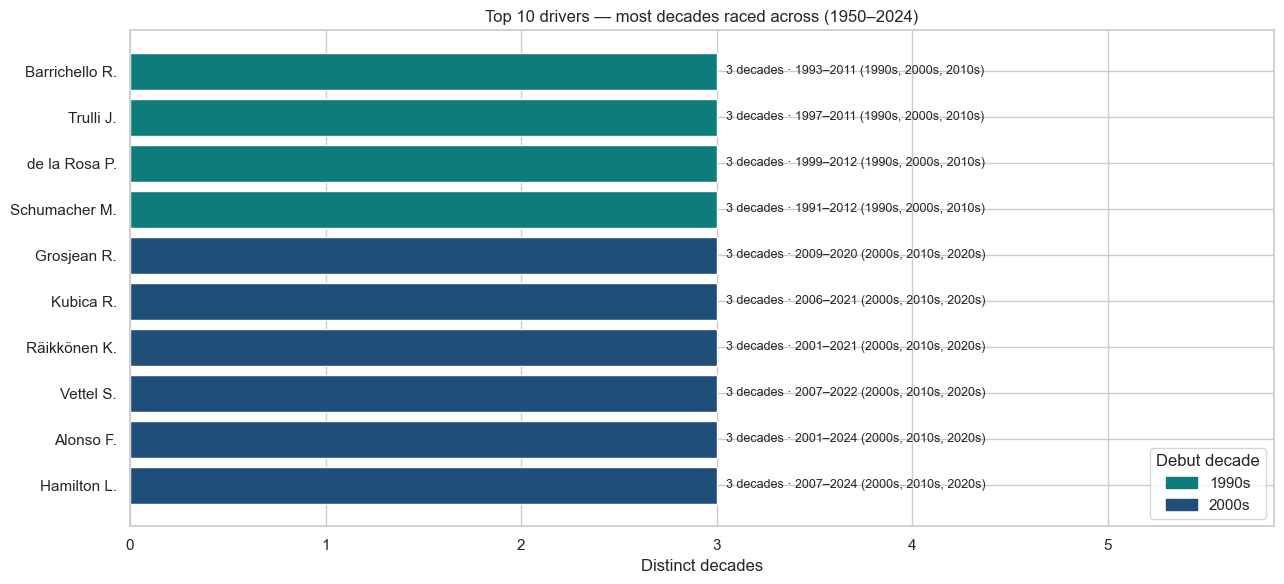

In [343]:
driver_year_pairs = (
    results.merge(races[['raceId', 'year']], on='raceId')
    [['driverId', 'year']].drop_duplicates()
)
driver_year_pairs['decade'] = (driver_year_pairs['year'] // 10) * 10

decades_per_driver = (
    driver_year_pairs.groupby('driverId')
    .agg(decades=('decade', 'nunique'),
         decade_list=('decade', lambda s: ', '.join(f'{d}s' for d in sorted(s.unique()))),
         first_year=('year', 'min'),
         last_year=('year', 'max'))
    .reset_index()
    .merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
)
decades_per_driver['driver'] = decades_per_driver['surname'] + ' ' + decades_per_driver['forename'].str[0] + '.'
decades_per_driver['debut_decade'] = (decades_per_driver['first_year'] // 10) * 10

top10_decades = (decades_per_driver
                 .sort_values(['decades', 'last_year'], ascending=[False, False])
                 .head(10)
                 .sort_values('decades'))

print('Top 10 drivers by number of decades raced:')
print(top10_decades.sort_values('decades', ascending=False)
      [['driver', 'decades', 'first_year', 'last_year', 'decade_list']]
      .to_string(index=False))

plt.figure(figsize=(13, 6))
bar_colors = [DECADE_COLORS[d] for d in top10_decades['debut_decade']]
plt.barh(range(len(top10_decades)), top10_decades['decades'], color=bar_colors)
plt.yticks(range(len(top10_decades)), top10_decades['driver'])

for i, row in enumerate(top10_decades.itertuples()):
    plt.text(row.decades + 0.05, i,
             f'{row.decades} decades · {int(row.first_year)}–{int(row.last_year)} ({row.decade_list})',
             va='center', fontsize=9)

used = sorted(top10_decades['debut_decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade', loc='lower right', frameon=True)

plt.title('Top 10 drivers — most decades raced across (1950–2024)')
plt.xlabel('Distinct decades')
plt.ylabel('')
plt.xlim(0, top10_decades['decades'].max() * 1.95)
plt.tight_layout()
show_and_save('2.5_most_decades.png')


**SQL equivalent**
```sql
-- 2.5: Drivers across the most decades (year // 10 buckets)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    COUNT(DISTINCT (ra.year / 10) * 10) AS decades,
    MIN(ra.year) AS first_year,
    MAX(ra.year) AS last_year
FROM   results r
JOIN   races   ra ON r.raceId   = ra.raceId
JOIN   drivers d  ON r.driverId = d.driverId
WHERE  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY r.driverId
ORDER  BY decades DESC, last_year DESC
LIMIT  10;
```


### Chart 2.6 — Drivers who raced across the most eras

Eras are the 9 chunks defined in the *Statistics for each Era* notebook (Pre-aerodynamic → Hybrid V6 Turbo). Mapping a year to an era requires explicit boundaries — they are not all 10 years long. A driver who raced 1993–2001 spans **3 eras** (Active suspension → Driver-aid ban → V10), not 2 decades.

Inline mini-eras_df below so this chart is self-contained — same boundaries as the era notebook.


Top 10 drivers by number of eras raced:
        driver  eras  first_year  last_year
    Mansell N.     4        1980       1995
     Moreno R.     4        1982       1995
   Alboreto M.     4        1981       1994
 de Cesaris A.     4        1980       1994
Barrichello R.     4        1993       2011
 Schumacher M.     4        1991       2012
  Räikkönen K.     3        2001       2021
     Alonso F.     3        2001       2024
     Button J.     3        2000       2017
      Massa F.     3        2002       2017

Era list per driver:
  Mansell N.         · 4 eras · Wings & aerodynamics, Turbo era, Active suspension / post-turbo, Driver-aid ban / pre-V10 dominance
  Moreno R.          · 4 eras · Wings & aerodynamics, Turbo era, Active suspension / post-turbo, Driver-aid ban / pre-V10 dominance
  Alboreto M.        · 4 eras · Wings & aerodynamics, Turbo era, Active suspension / post-turbo, Driver-aid ban / pre-V10 dominance
  de Cesaris A.      · 4 eras · Wings & aerodynamics, Turb

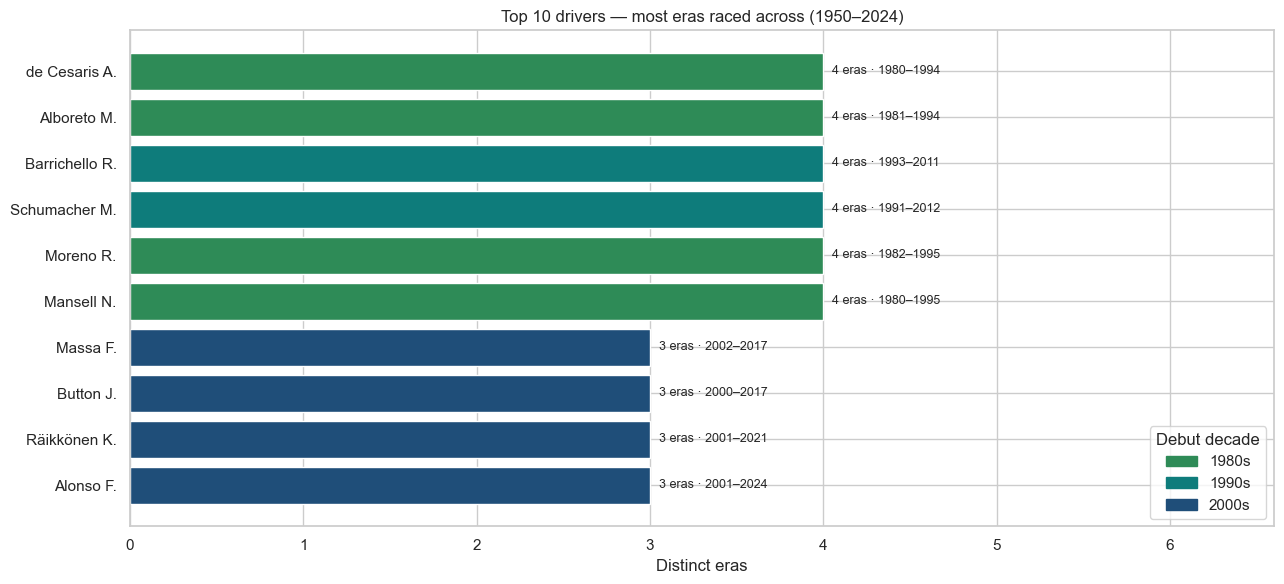

In [344]:
# Era boundaries — same as in 'Statistics for each Era.ipynb'
eras_df = pd.DataFrame([
    (1, 'Pre-aerodynamic / Front-engine',     1950, 1958),
    (2, 'Rear-engine revolution',             1959, 1967),
    (3, 'Wings & aerodynamics',               1968, 1982),
    (4, 'Turbo era',                          1983, 1988),
    (5, 'Active suspension / post-turbo',     1989, 1993),
    (6, 'Driver-aid ban / pre-V10 dominance', 1994, 1999),
    (7, 'V10 era',                            2000, 2005),
    (8, 'V8 / Limited electronics',           2006, 2013),
    (9, 'Hybrid V6 Turbo',                    2014, 2025),
], columns=['era_id', 'name_en', 'year_start', 'year_end'])


def year_to_era(year):
    match = eras_df[(eras_df['year_start'] <= year) & (eras_df['year_end'] >= year)]
    return match['era_id'].iloc[0] if len(match) else None


# Map each (driver, year) row to an era_id
driver_year_pairs['era_id'] = driver_year_pairs['year'].apply(year_to_era)

eras_per_driver = (
    driver_year_pairs.dropna(subset=['era_id'])
    .groupby('driverId')
    .agg(eras=('era_id', 'nunique'),
         era_list=('era_id', lambda s: ', '.join(eras_df.set_index('era_id')
                                                 .loc[sorted(s.unique()), 'name_en'].tolist())),
         first_year=('year', 'min'),
         last_year=('year', 'max'))
    .reset_index()
    .merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
)
eras_per_driver['driver'] = eras_per_driver['surname'] + ' ' + eras_per_driver['forename'].str[0] + '.'
eras_per_driver['debut_decade'] = (eras_per_driver['first_year'] // 10) * 10

top10_eras = (eras_per_driver
              .sort_values(['eras', 'last_year'], ascending=[False, False])
              .head(10)
              .sort_values('eras'))

print('Top 10 drivers by number of eras raced:')
print(top10_eras.sort_values('eras', ascending=False)
      [['driver', 'eras', 'first_year', 'last_year']]
      .to_string(index=False))
print()
print('Era list per driver:')
for r in top10_eras.sort_values('eras', ascending=False).itertuples():
    print(f'  {r.driver:18s} · {r.eras} eras · {r.era_list}')

plt.figure(figsize=(13, 6))
bar_colors = [DECADE_COLORS[d] for d in top10_eras['debut_decade']]
plt.barh(range(len(top10_eras)), top10_eras['eras'], color=bar_colors)
plt.yticks(range(len(top10_eras)), top10_eras['driver'])

for i, row in enumerate(top10_eras.itertuples()):
    plt.text(row.eras + 0.05, i,
             f'{row.eras} eras · {int(row.first_year)}–{int(row.last_year)}',
             va='center', fontsize=9)

used = sorted(top10_eras['debut_decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade', loc='lower right', frameon=True)

plt.title('Top 10 drivers — most eras raced across (1950–2024)')
plt.xlabel('Distinct eras')
plt.ylabel('')
plt.xlim(0, top10_eras['eras'].max() * 1.65)
plt.tight_layout()
show_and_save('2.6_most_eras.png')


**SQL equivalent**
```sql
-- 2.6: Drivers across the most eras (eras table joined on year ranges)
WITH eras(era_id, name_en, year_start, year_end) AS (
    VALUES
        (1, 'Pre-aerodynamic / Front-engine',     1950, 1958),
        (2, 'Rear-engine revolution',             1959, 1967),
        (3, 'Wings & aerodynamics',               1968, 1982),
        (4, 'Turbo era',                          1983, 1988),
        (5, 'Active suspension / post-turbo',     1989, 1993),
        (6, 'Driver-aid ban / pre-V10 dominance', 1994, 1999),
        (7, 'V10 era',                            2000, 2005),
        (8, 'V8 / Limited electronics',           2006, 2013),
        (9, 'Hybrid V6 Turbo',                    2014, 2025)
)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    COUNT(DISTINCT e.era_id) AS eras,
    MIN(ra.year)             AS first_year,
    MAX(ra.year)             AS last_year
FROM   results r
JOIN   races   ra ON r.raceId   = ra.raceId
JOIN   eras    e  ON ra.year BETWEEN e.year_start AND e.year_end
JOIN   drivers d  ON r.driverId = d.driverId
WHERE  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY r.driverId
ORDER  BY eras DESC, last_year DESC
LIMIT  10;
```


### Chart 2.7 — Longest gap: first race win → last race win

Among drivers with **at least 2 wins** (gap is meaningless with only 1), measure the year of the first win vs. the year of the last win. The longest gap is one driver's "career window of being a winner".

Top 10 — many will be multi-decade legends (Schumacher, Hamilton). Less obvious entries are drivers who won young, disappeared, then came back.


Top 10 drivers by longest first→last win gap:
       driver  gap  first_win  last_win  wins
  Hamilton L.   17       2007      2024   105
 Räikkönen K.   15       2003      2018    21
Schumacher M.   14       1992      2006    91
     Prost A.   12       1981      1993    51
     Lauda N.   11       1974      1985    25
    Vettel S.   11       2008      2019    53
    Berger G.   11       1986      1997    10
   Brabham J.   11       1959      1970    14
    Piquet N.   11       1980      1991    23
    Alonso F.   10       2003      2013    32


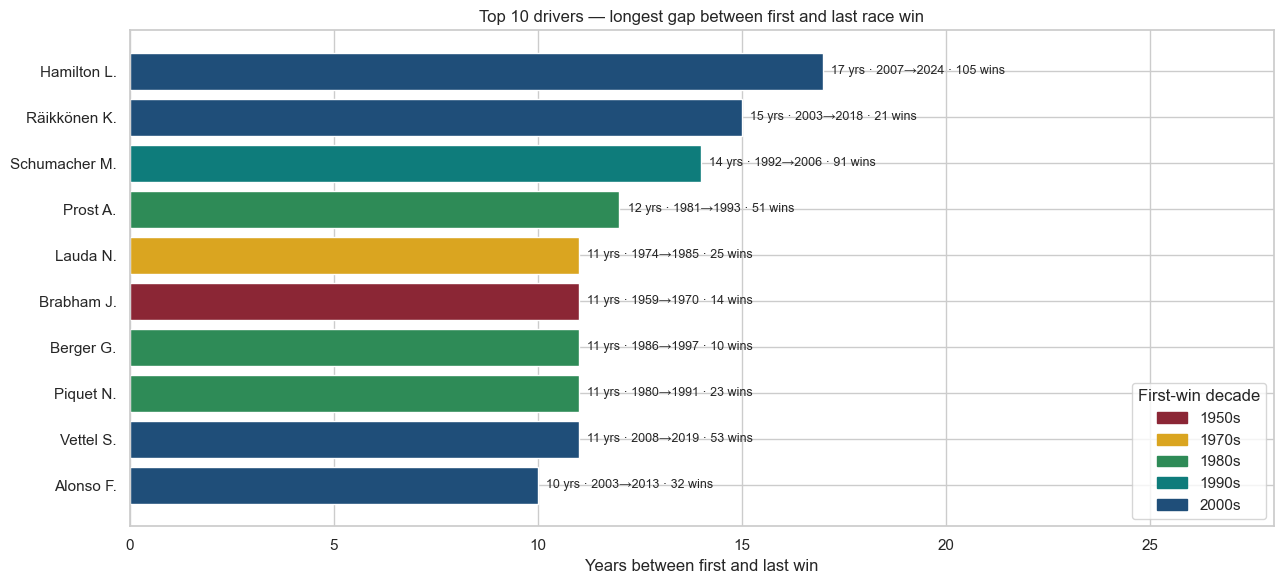

In [345]:
wins = (
    results[results['positionOrder'] == 1]
    .merge(races[['raceId', 'year']], on='raceId')
    [['driverId', 'year']]
)

win_gap = (
    wins.groupby('driverId')
    .agg(wins=('year', 'count'),
         first_win=('year', 'min'),
         last_win=('year', 'max'))
    .reset_index()
)
win_gap['gap'] = win_gap['last_win'] - win_gap['first_win']

win_gap = (win_gap[win_gap['wins'] >= 2]
           .merge(drivers[['driverId', 'forename', 'surname']], on='driverId'))
win_gap['driver'] = win_gap['surname'] + ' ' + win_gap['forename'].str[0] + '.'
win_gap['debut_decade'] = (win_gap['first_win'] // 10) * 10

top10_win_gap = (win_gap.sort_values('gap', ascending=False)
                 .head(10)
                 .sort_values('gap'))

print('Top 10 drivers by longest first→last win gap:')
print(top10_win_gap.sort_values('gap', ascending=False)
      [['driver', 'gap', 'first_win', 'last_win', 'wins']].to_string(index=False))

plt.figure(figsize=(13, 6))
bar_colors = [DECADE_COLORS[d] for d in top10_win_gap['debut_decade']]
plt.barh(range(len(top10_win_gap)), top10_win_gap['gap'], color=bar_colors)
plt.yticks(range(len(top10_win_gap)), top10_win_gap['driver'])

for i, row in enumerate(top10_win_gap.itertuples()):
    plt.text(row.gap + 0.2, i,
             f'{row.gap} yrs · {int(row.first_win)}→{int(row.last_win)} · {row.wins} wins',
             va='center', fontsize=9)

used = sorted(top10_win_gap['debut_decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='First-win decade', loc='lower right', frameon=True)

plt.title('Top 10 drivers — longest gap between first and last race win')
plt.xlabel('Years between first and last win')
plt.ylabel('')
plt.xlim(0, top10_win_gap['gap'].max() * 1.65)
plt.tight_layout()
show_and_save('2.7_first_last_win_gap.png')


**SQL equivalent**
```sql
-- 2.7: Longest first→last win gap (drivers with >=2 wins)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    MAX(ra.year) - MIN(ra.year) AS gap,
    MIN(ra.year)                AS first_win,
    MAX(ra.year)                AS last_win,
    COUNT(*)                    AS wins
FROM   results r
JOIN   races   ra ON r.raceId   = ra.raceId
JOIN   drivers d  ON r.driverId = d.driverId
WHERE  ra.name NOT LIKE '%Indianapolis%'
  AND  r.positionOrder = 1
GROUP  BY r.driverId
HAVING COUNT(*) >= 2
ORDER  BY gap DESC
LIMIT  10;
```


### Chart 2.8 — Longest gap: first race → last race

Same shape as 2.7 but the threshold is participation, not winning. Catches the journeymen and the comeback drivers — Riccardo Patrese (1977–1993), Graham Hill, etc.

Note that this is **gap in calendar years**, NOT continuous activity — a driver who raced 1985 and 2003 spans 18 years but with a long break in between. Useful nuance for the F1 history class: "longest career span" ≠ "most starts" (2.1) ≠ "most decades" (2.5).


Top 10 drivers by longest first→last race gap:
        driver  gap  first_race  last_race  starts
     Alonso F.   23        2001       2024     404
 Schumacher M.   21        1991       2012     308
  Räikkönen K.   20        2001       2021     352
Barrichello R.   18        1993       2011     326
   Hamilton L.   17        2007       2024     356
       Hill G.   17        1958       1975     179
     Button J.   17        2000       2017     309
    Patrese R.   16        1977       1993     257
     Badoer L.   16        1993       2009      58
    Bonnier J.   15        1956       1971     109


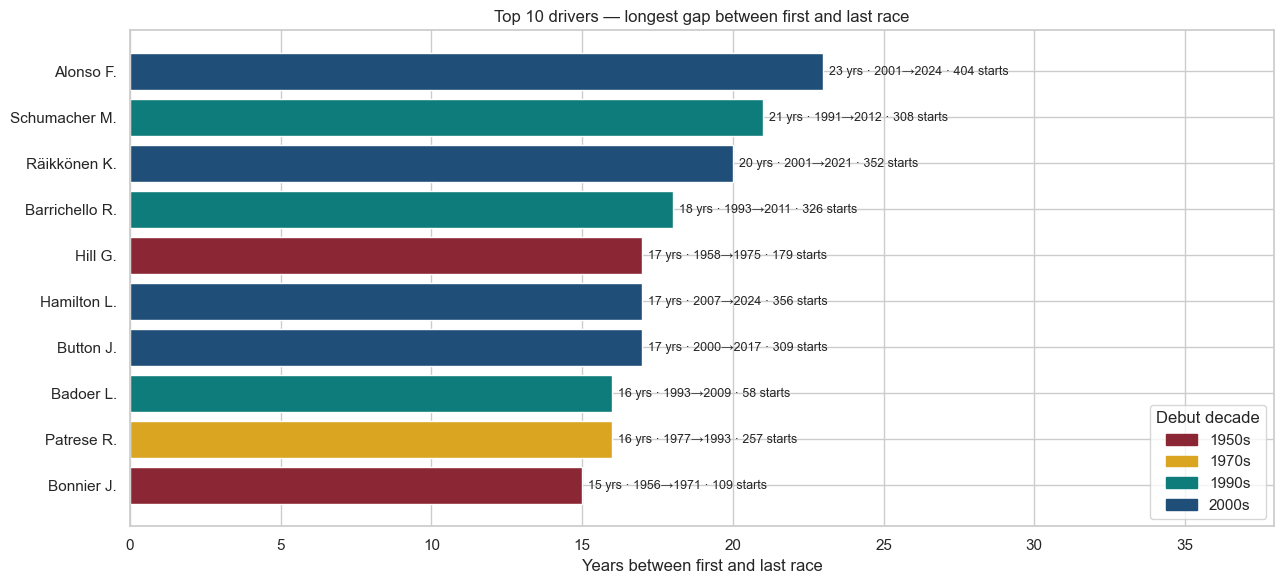

In [346]:
all_years = (
    results.merge(races[['raceId', 'year']], on='raceId')
    [['driverId', 'year']]
)

race_gap = (
    all_years.groupby('driverId')
    .agg(starts=('year', 'count'),
         first_race=('year', 'min'),
         last_race=('year', 'max'))
    .reset_index()
)
race_gap['gap'] = race_gap['last_race'] - race_gap['first_race']

race_gap = (race_gap[race_gap['starts'] >= 2]
            .merge(drivers[['driverId', 'forename', 'surname']], on='driverId'))
race_gap['driver'] = race_gap['surname'] + ' ' + race_gap['forename'].str[0] + '.'
race_gap['debut_decade'] = (race_gap['first_race'] // 10) * 10

top10_race_gap = (race_gap.sort_values('gap', ascending=False)
                  .head(10)
                  .sort_values('gap'))

print('Top 10 drivers by longest first→last race gap:')
print(top10_race_gap.sort_values('gap', ascending=False)
      [['driver', 'gap', 'first_race', 'last_race', 'starts']].to_string(index=False))

plt.figure(figsize=(13, 6))
bar_colors = [DECADE_COLORS[d] for d in top10_race_gap['debut_decade']]
plt.barh(range(len(top10_race_gap)), top10_race_gap['gap'], color=bar_colors)
plt.yticks(range(len(top10_race_gap)), top10_race_gap['driver'])

for i, row in enumerate(top10_race_gap.itertuples()):
    plt.text(row.gap + 0.2, i,
             f'{row.gap} yrs · {int(row.first_race)}→{int(row.last_race)} · {row.starts} starts',
             va='center', fontsize=9)

used = sorted(top10_race_gap['debut_decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade', loc='lower right', frameon=True)

plt.title('Top 10 drivers — longest gap between first and last race')
plt.xlabel('Years between first and last race')
plt.ylabel('')
plt.xlim(0, top10_race_gap['gap'].max() * 1.65)
plt.tight_layout()
show_and_save('2.8_first_last_race_gap.png')


**SQL equivalent**
```sql
-- 2.8: Longest first→last race gap (career span in calendar years)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    MAX(ra.year) - MIN(ra.year) AS gap,
    MIN(ra.year)                AS first_race,
    MAX(ra.year)                AS last_race,
    COUNT(*)                    AS starts
FROM   results r
JOIN   races   ra ON r.raceId   = ra.raceId
JOIN   drivers d  ON r.driverId = d.driverId
WHERE  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY r.driverId
HAVING COUNT(*) >= 2
ORDER  BY gap DESC
LIMIT  10;
```


## Q1 — Drivers who never reached a milestone

The opening funnel (Chart 2.0, near the top of Section 2) already shows the overall drop-off from "all drivers" to "race winner". The next three charts zoom in on each "never reached" cohort and rank its members **by race starts**, surfacing drivers who built long careers without ever clearing the bar.

| Chart | Cohort | Position threshold |
|---|---|---|
| 2.9  | Never won a race    | P1     |
| 2.10 | Never reached podium | P1–P3 |
| 2.11 | Never finished top 10 | P1–P10 |

Ranking by **race starts** rather than career-year span is deliberate: Luca Badoer raced 1993–2009 but made only 58 starts (Ferrari test-driver role), so years-active would mislead.


In [347]:
# Step 3 — helper to build "top 15 drivers who never reached X" by race count
def never_reached(milestone_set):
    """Return (top15_df, never_count) for drivers who never reached the milestone."""
    never_ids = all_ids - milestone_set

    nw_results = (
        results[results['driverId'].isin(never_ids)]
        .merge(races[['raceId', 'year']], on='raceId')
    )

    df = (
        nw_results.groupby('driverId')
        .agg(races=('raceId', 'count'),
             first_year=('year', 'min'),
             last_year=('year', 'max'))
        .reset_index()
        .merge(drivers[['driverId', 'forename', 'surname', 'nationality']],
               on='driverId')
    )

    df['driver']  = df['surname'] + ' ' + df['forename'].str[0] + '.'
    df['period']  = df['first_year'].astype(str) + '–' + df['last_year'].astype(str)
    df['decade']  = (df['first_year'] // 10) * 10
    return df.nlargest(15, 'races'), len(never_ids)


# Categorical color per debut decade — deliberately distinct hues
DECADE_COLORS = {
    1950: '#8B2635',  # burgundy
    1960: '#D2691E',  # chocolate orange
    1970: '#DAA520',  # goldenrod
    1980: '#2E8B57',  # sea green
    1990: '#0E7C7B',  # teal
    2000: '#1F4E79',  # navy blue
    2010: '#5B2A86',  # royal purple
    2020: '#3A3A3A',  # dark gray
}


def _hex_to_rgb(hex_color):
    """'#1F4E79' → (0.12, 0.31, 0.47) — used by the luminance check."""
    h = hex_color.lstrip('#')
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))


def _luminance(rgb):
    """Perceived brightness 0–1 using ITU-R BT.709 weights."""
    r, g, b = rgb[:3]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def plot_never(df, never_count, label, filename):
    bar_colors = [DECADE_COLORS[d] for d in df['decade']]

    plt.figure(figsize=(11, 6))
    sns.barplot(data=df, x='races', y='driver',
                hue='driver', palette=bar_colors, legend=False)

    for i, row in enumerate(df.itertuples()):
        # Period text — white on dark bars, dark on light bars
        bar_rgb = _hex_to_rgb(DECADE_COLORS[row.decade])
        text_color = 'white' if _luminance(bar_rgb) < 0.55 else '#1c1c1c'
        plt.text(row.races / 2, i, row.period,
                 va='center', ha='center',
                 fontsize=9, fontweight='bold',
                 color=text_color)
        plt.text(row.races + 2, i, f'{row.races}',
                 va='center', fontsize=9)

    # Decade legend — only decades that actually appear in this chart
    used = sorted(df['decade'].unique())
    handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
               for d in used]
    plt.legend(handles=handles, title='Debut decade',
               loc='lower right', frameon=True)

    plt.title(f'Top 15 drivers who never {label} — by race starts '
              f'(group total: {never_count})')
    plt.xlabel('Number of race starts')
    plt.ylabel('')
    plt.xlim(0, df['races'].max() * 1.10)
    plt.tight_layout()
    show_and_save(filename)

### Chart 2.9 — Top 15 drivers who never won a race

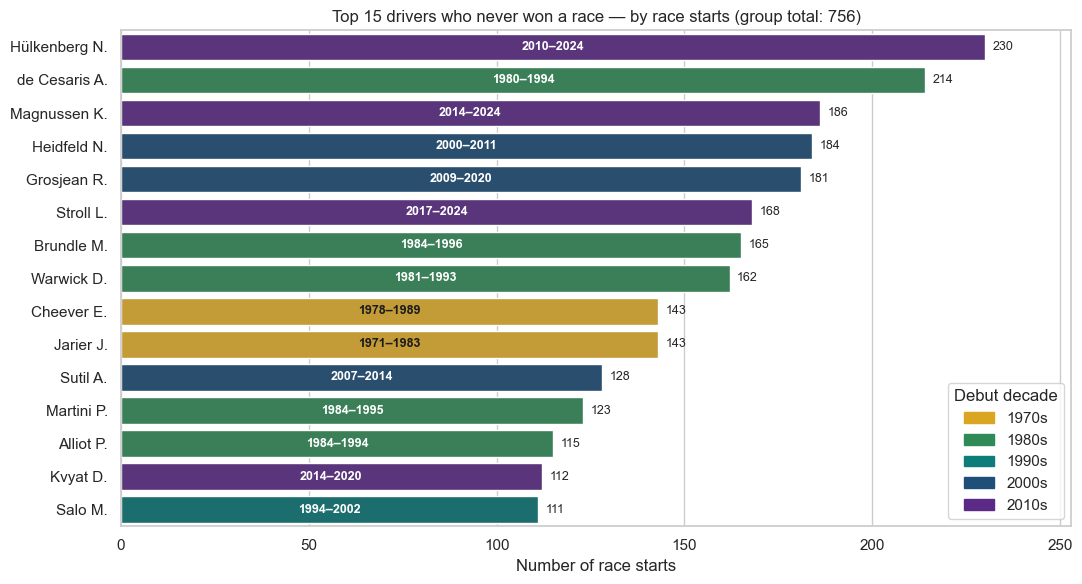

In [348]:
# Step 4a — drivers who NEVER won a race
never_won, n_never_won = never_reached(winner_ids)
plot_never(never_won, n_never_won, 'won a race',
           filename='2.9_never_won.png')

**SQL equivalent**
```sql
-- Top 15 drivers who NEVER reached the milestone — by total race starts
-- (change positionOrder threshold for each variant: =1 won, <=3 podium, <=10 top10)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    COUNT(*) AS starts,
    MIN(ra.year) AS first_year,
    MAX(ra.year) AS last_year
FROM   drivers d
JOIN   results r  ON d.driverId = r.driverId
JOIN   races   ra ON r.raceId   = ra.raceId
WHERE  d.driverId NOT IN (
           SELECT DISTINCT r2.driverId FROM results r2
           WHERE r2.positionOrder = 1     -- the milestone we exclude
       )
  AND  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY d.driverId
ORDER  BY starts DESC
LIMIT  15;
```

### Chart 2.10 — Top 15 drivers who never reached the podium

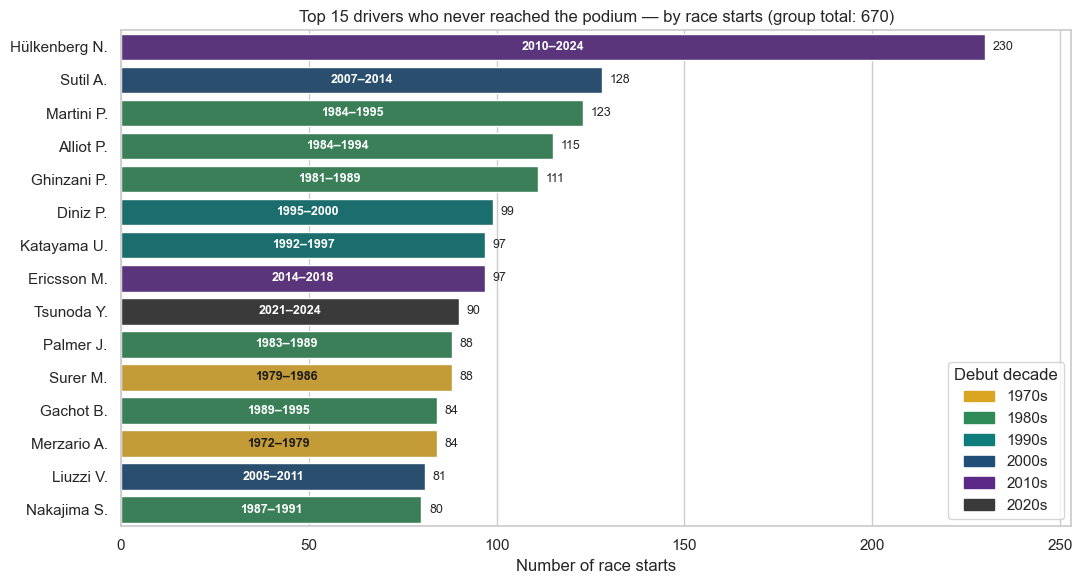

In [349]:
# Step 4b — drivers who NEVER reached the podium (P1–P3)
never_pod, n_never_pod = never_reached(podium_ids)
plot_never(never_pod, n_never_pod, 'reached the podium',
           filename='2.10_never_podium.png')

**SQL equivalent**
```sql
-- Top 15 drivers who NEVER reached the milestone — by total race starts
-- (change positionOrder threshold for each variant: =1 won, <=3 podium, <=10 top10)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    COUNT(*) AS starts,
    MIN(ra.year) AS first_year,
    MAX(ra.year) AS last_year
FROM   drivers d
JOIN   results r  ON d.driverId = r.driverId
JOIN   races   ra ON r.raceId   = ra.raceId
WHERE  d.driverId NOT IN (
           SELECT DISTINCT r2.driverId FROM results r2
           WHERE r2.positionOrder = 1     -- the milestone we exclude
       )
  AND  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY d.driverId
ORDER  BY starts DESC
LIMIT  15;
```

### Chart 2.11 — Top 15 drivers who never finished in the top 10

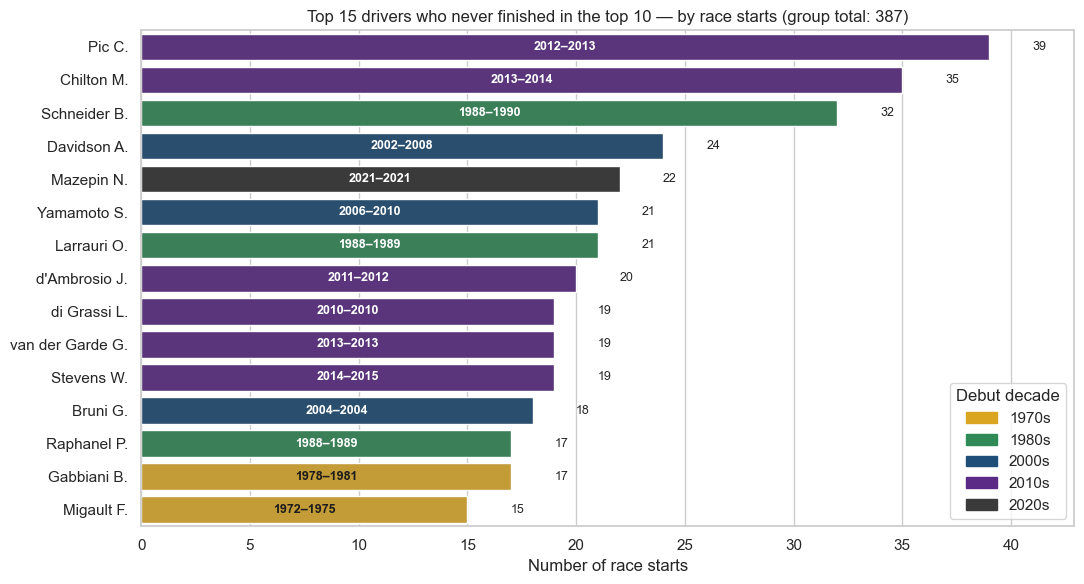

In [350]:
# Step 4c — drivers who NEVER finished in the top 10 (no points)
never_t10, n_never_t10 = never_reached(top10_ids)
plot_never(never_t10, n_never_t10, 'finished in the top 10',
           filename='2.11_never_top10.png')

**SQL equivalent**
```sql
-- Top 15 drivers who NEVER reached the milestone — by total race starts
-- (change positionOrder threshold for each variant: =1 won, <=3 podium, <=10 top10)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    COUNT(*) AS starts,
    MIN(ra.year) AS first_year,
    MAX(ra.year) AS last_year
FROM   drivers d
JOIN   results r  ON d.driverId = r.driverId
JOIN   races   ra ON r.raceId   = ra.raceId
WHERE  d.driverId NOT IN (
           SELECT DISTINCT r2.driverId FROM results r2
           WHERE r2.positionOrder = 1     -- the milestone we exclude
       )
  AND  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY d.driverId
ORDER  BY starts DESC
LIMIT  15;
```

## Q2 + Q3 — Youngest & oldest at three milestones *(one combined chart)*

Three milestones, ordered from rare to legendary:

| Milestone | Filter |
|---|---|
| **Pole sitter** (Q3 winner) | `results.grid == 1` — works for the whole F1 history (1950+), unlike `qualifying.csv` which only goes back to ~1994 |
| **Podium** | `results.positionOrder <= 3` |
| **Race winner** | `results.positionOrder == 1` |

**One side-by-side chart:**
- **Left panel** — Youngest at each milestone (top 3 unique drivers per milestone)
- **Right panel** — Oldest at each milestone (same)

Each bar shows: year + Grand Prix + constructor (team) inside; age in years + months outside. A summary insight prints below the chart for both halves.

In [351]:
# Step 1 — single big merge: results × races × drivers × constructors
races_dt = (races[['raceId', 'year', 'date', 'name']]
            .rename(columns={'name': 'gp'})
            .copy())
races_dt['date'] = pd.to_datetime(races_dt['date'])

drv_dt = drivers[['driverId', 'forename', 'surname', 'dob']].copy()
drv_dt['dob'] = pd.to_datetime(drv_dt['dob'])

team_dt = constructors[['constructorId', 'name']].rename(columns={'name': 'team'})

ages = (
    results[['driverId', 'raceId', 'constructorId', 'positionOrder', 'grid']]
    .merge(races_dt, on='raceId')
    .merge(drv_dt,   on='driverId')
    .merge(team_dt,  on='constructorId')
)

ages['age']    = (ages['date'] - ages['dob']).dt.days / 365.25
ages['driver'] = ages['surname'] + ' ' + ages['forename'].str[0] + '.'
ages = ages.dropna(subset=['age'])  # defensive: drop rows where dob/date missing

print(f'Race rows           : {len(ages):,}')
print(f'Pole rows (grid==1) : {(ages["grid"] == 1).sum():,}')
print(f'Podium rows (P1-P3) : {(ages["positionOrder"] <= 3).sum():,}')
print(f'Winner rows (P1)    : {(ages["positionOrder"] == 1).sum():,}')

Race rows           : 26,354
Pole rows (grid==1) : 1,125
Podium rows (P1-P3) : 3,361
Winner rows (P1)    : 1,117


In [352]:
# Step 2 — top 3 youngest / oldest unique drivers PER milestone
def age_extremes(df, n=3):
    young = df.sort_values('age').drop_duplicates('driverId').head(n)
    old   = df.sort_values('age', ascending=False).drop_duplicates('driverId').head(n)
    return young, old


poles_age   = ages[ages['grid'] == 1]
podium_age  = ages[ages['positionOrder'] <= 3]
winners_age = ages[ages['positionOrder'] == 1]

young_pole, old_pole = age_extremes(poles_age)
young_pod,  old_pod  = age_extremes(podium_age)
young_win,  old_win  = age_extremes(winners_age)

print('YOUNGEST per milestone:')
for label, df in [('Pole', young_pole), ('Podium', young_pod), ('Winner', young_win)]:
    print(f'\n  {label}:')
    print('  ' + df[['driver', 'age', 'year', 'gp', 'team']]
              .to_string(index=False).replace('\n', '\n  '))

YOUNGEST per milestone:

  Pole:
      driver       age  year                   gp       team
   Vettel S. 21.201916  2008   Italian Grand Prix Toro Rosso
  Leclerc C. 21.453799  2019   Bahrain Grand Prix    Ferrari
   Alonso F. 21.648186  2003 Malaysian Grand Prix    Renault

  Podium:
         driver       age  year                    gp     team
  Verstappen M. 18.622861  2016    Spanish Grand Prix Red Bull
      Stroll L. 18.655715  2017 Azerbaijan Grand Prix Williams
      Norris L. 20.643395  2020   Austrian Grand Prix  McLaren

  Winner:
         driver       age  year                 gp       team
  Verstappen M. 18.622861  2016 Spanish Grand Prix   Red Bull
      Vettel S. 21.201916  2008 Italian Grand Prix Toro Rosso
     Leclerc C. 21.875428  2019 Belgian Grand Prix    Ferrari


In [353]:
# Combined-chart helper — one figure with two side-by-side panels
# (youngest on the left, oldest on the right), shared milestone legend.
MILESTONE_COLORS = {
    'Pole sitter (grid P1)': '#1F4E79',  # navy
    'Podium (P1–P3)':        '#5B2A86',  # purple
    'Race winner (P1)':      '#8B2635',  # burgundy
}


def _format_age(age_years):
    """Convert decimal years (18.94) → '18y 11m'."""
    years = int(age_years)
    months = int(round((age_years - years) * 12))
    if months == 12:
        years += 1
        months = 0
    return f'{years}y {months}m'


def _short_gp(name):
    """'Spanish Grand Prix' → 'Spanish GP'."""
    return name.replace('Grand Prix', 'GP').strip()


def _draw_age_panel(ax, pole, pod, win, panel_title):
    """Draw 9 horizontal bars (3 milestones × 3 drivers) into the given axes."""
    rows = []
    for ms, df in [('Pole sitter (grid P1)', pole),
                   ('Podium (P1–P3)',        pod),
                   ('Race winner (P1)',      win)]:
        for r in df.itertuples():
            rows.append({
                'milestone': ms,
                'driver':    r.driver,
                'age':       r.age,
                'year':      int(r.year),
                'gp':        _short_gp(r.gp),
                'team':      r.team,
            })
    df = pd.DataFrame(rows)

    colors = [MILESTONE_COLORS[m] for m in df['milestone']]
    ax.barh(range(len(df)), df['age'], color=colors)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['driver'])

    for i, row in df.iterrows():
        ax.text(0.5, i,
                f'{row.year} · {row.gp[:22]}\n{row.team[:22]}',
                va='center', ha='left',
                fontsize=8.5, color='white', fontweight='bold')
        ax.text(row.age + 0.5, i,
                _format_age(row.age),
                va='center', fontsize=9)

    for sep_y in [2.5, 5.5]:
        ax.axhline(y=sep_y, color='gray', linestyle=':',
                   alpha=0.5, linewidth=1)

    ax.set_title(panel_title, fontsize=11)
    ax.set_xlabel('Age (years)')
    ax.invert_yaxis()
    ax.set_xlim(0, df['age'].max() * 1.20)


def plot_age_milestones_combined(young_pole, young_pod, young_win,
                                 old_pole, old_pod, old_win,
                                 filename='2.12_age_milestones.png'):
    """Side-by-side: youngest (left) vs oldest (right) at the three milestones.

    Replaces the two separate Q2/Q3 charts so the contrast is readable in
    one glance — the previous version forced the reader to flip back and
    forth between two near-identical layouts.
    """
    fig, (ax_y, ax_o) = plt.subplots(1, 2, figsize=(20, 7))

    _draw_age_panel(ax_y, young_pole, young_pod, young_win,
                    'Q2 — Youngest at each milestone')
    _draw_age_panel(ax_o, old_pole, old_pod, old_win,
                    'Q3 — Oldest at each milestone')

    handles = [plt.Rectangle((0, 0), 1, 1, color=c, label=m)
               for m, c in MILESTONE_COLORS.items()]
    fig.legend(handles=handles, loc='upper center',
               bbox_to_anchor=(0.5, 0.05), ncol=3,
               frameon=True, title='Milestone')

    fig.suptitle(
        'Q2 + Q3 — Youngest & Oldest at three F1 milestones '
        '(top 3 unique drivers per milestone)',
        fontsize=13, y=0.99)

    fig.tight_layout(rect=[0, 0.10, 1, 0.96])
    fig.text(0.5, 0.005,
             '* Indianapolis 500 (1950–1960) excluded — was nominally F1 but a separate American oval race.',
             ha='center', va='bottom',
             fontsize=8, style='italic', color='gray')
    show_and_save(filename)

    # Insight pair — gap between pole and winner extremes, both directions
    yp, yw = young_pole['age'].iloc[0], young_win['age'].iloc[0]
    op, ow = old_pole['age'].iloc[0],   old_win['age'].iloc[0]

    if yp < yw:
        print(f'\nYoungest: pole came {_format_age(yw - yp)} before the win — '
              f'pure speed arrives before race-winning craft.')
    else:
        print(f'\nYoungest: the youngest pole sitter was actually '
              f'{_format_age(yp - yw)} older than the youngest race winner — '
              f'unusual; the win came before the perfect Saturday lap.')

    if op > ow:
        print(f'Oldest:   pole lasted {_format_age(op - ow)} longer into a career '
              f'than race-winning ability.')
    else:
        print(f'Oldest:   the oldest race winner outlasted the oldest pole sitter '
              f'by {_format_age(ow - op)} — race-craft endured longer than qualifying pace.')

### Chart 2.12 — Q2 + Q3 — Youngest & Oldest at pole / podium / race winner *(combined)*

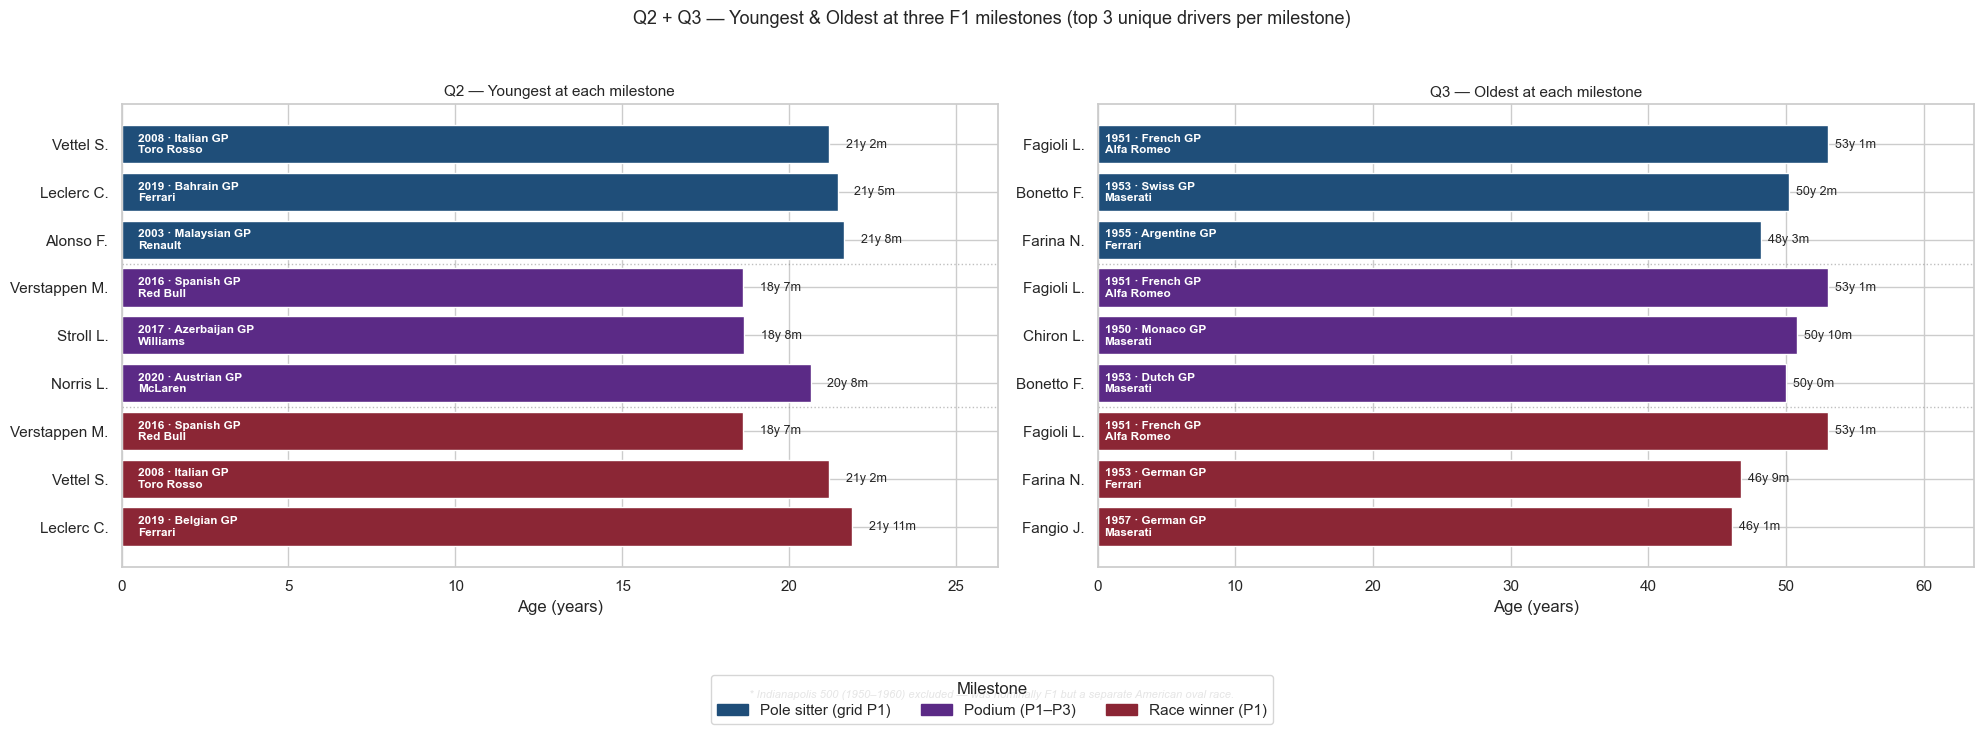


Youngest: the youngest pole sitter was actually 2y 7m older than the youngest race winner — unusual; the win came before the perfect Saturday lap.
Oldest:   the oldest race winner outlasted the oldest pole sitter by 0y 0m — race-craft endured longer than qualifying pace.


In [354]:
# Combined chart — youngest (left) vs oldest (right) at pole/podium/winner
plot_age_milestones_combined(
    young_pole, young_pod, young_win,
    old_pole, old_pod, old_win,
    filename='2.12_age_milestones.png',
)

**SQL equivalent**
```sql
-- Q2/Q3: Youngest (or oldest) at pole / podium / race winner.
-- Replace MIN(age) with MAX(age) for "oldest". Repeat per milestone:
--   Pole sitter: r.grid = 1
--   Podium    : r.positionOrder <= 3
--   Race winner: r.positionOrder = 1
WITH driver_age AS (
    SELECT
        r.driverId, ra.year, ra.name AS gp, c.name AS team,
        r.positionOrder, r.grid,
        d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
        (julianday(ra.date) - julianday(d.dob)) / 365.25     AS age
    FROM   results       r
    JOIN   races         ra ON r.raceId        = ra.raceId
    JOIN   drivers       d  ON r.driverId      = d.driverId
    JOIN   constructors  c  ON r.constructorId = c.constructorId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
      AND  d.dob IS NOT NULL
)
-- Top 3 unique-driver YOUNGEST pole sitters
SELECT *
FROM (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY driverId ORDER BY age) AS rn
    FROM   driver_age WHERE grid = 1
) t
WHERE  rn = 1
ORDER  BY age
LIMIT  3;
```

### Chart 2.13 — Youngest & oldest race participants, split by era (pre-2000 vs 2000+)

Same baseline as before — youngest/oldest age at *any* race start, regardless of result. A 17-year-old who DNFs on lap 3 still counts.

Splitting the field at the year **2000** (a round-number cutoff, no specific F1 rule behind it) gives a quick "old days vs modern era" contrast. Top 3 unique drivers per quadrant: youngest pre-2000, youngest 2000+, oldest pre-2000, oldest 2000+.

Indianapolis-500 entries (1950–1960) are already excluded globally — they were nominally F1 but a separate American oval race.



YOUNGEST pre-2000 (top 3 unique):
      driver       age  year                 gp         team
  Monarch T. 18.146475  1963 Mexican Grand Prix Lotus-Climax
Thackwell M. 19.422313  1980   Dutch Grand Prix       Arrows
Rodríguez R. 19.570157  1961 Italian Grand Prix      Ferrari

YOUNGEST 2000+ (top 3 unique):
       driver       age  year                       gp       team
Verstappen M. 17.453799  2015    Australian Grand Prix Toro Rosso
    Stroll L. 18.406571  2017    Australian Grand Prix   Williams
   Bearman O. 18.836413  2024 Saudi Arabian Grand Prix    Ferrari

OLDEST pre-2000 (top 3 unique):
      driver       age  year                 gp     team
   Chiron L. 58.787132  1958  Monaco Grand Prix Maserati
Étancelin P. 55.518138  1952  French Grand Prix Maserati
    Legat A. 54.633812  1953 Belgian Grand Prix  Veritas

OLDEST 2000+ (top 3 unique):
       driver       age  year                   gp         team
Schumacher M. 43.893224  2012 Brazilian Grand Prix     Mercedes
    Al

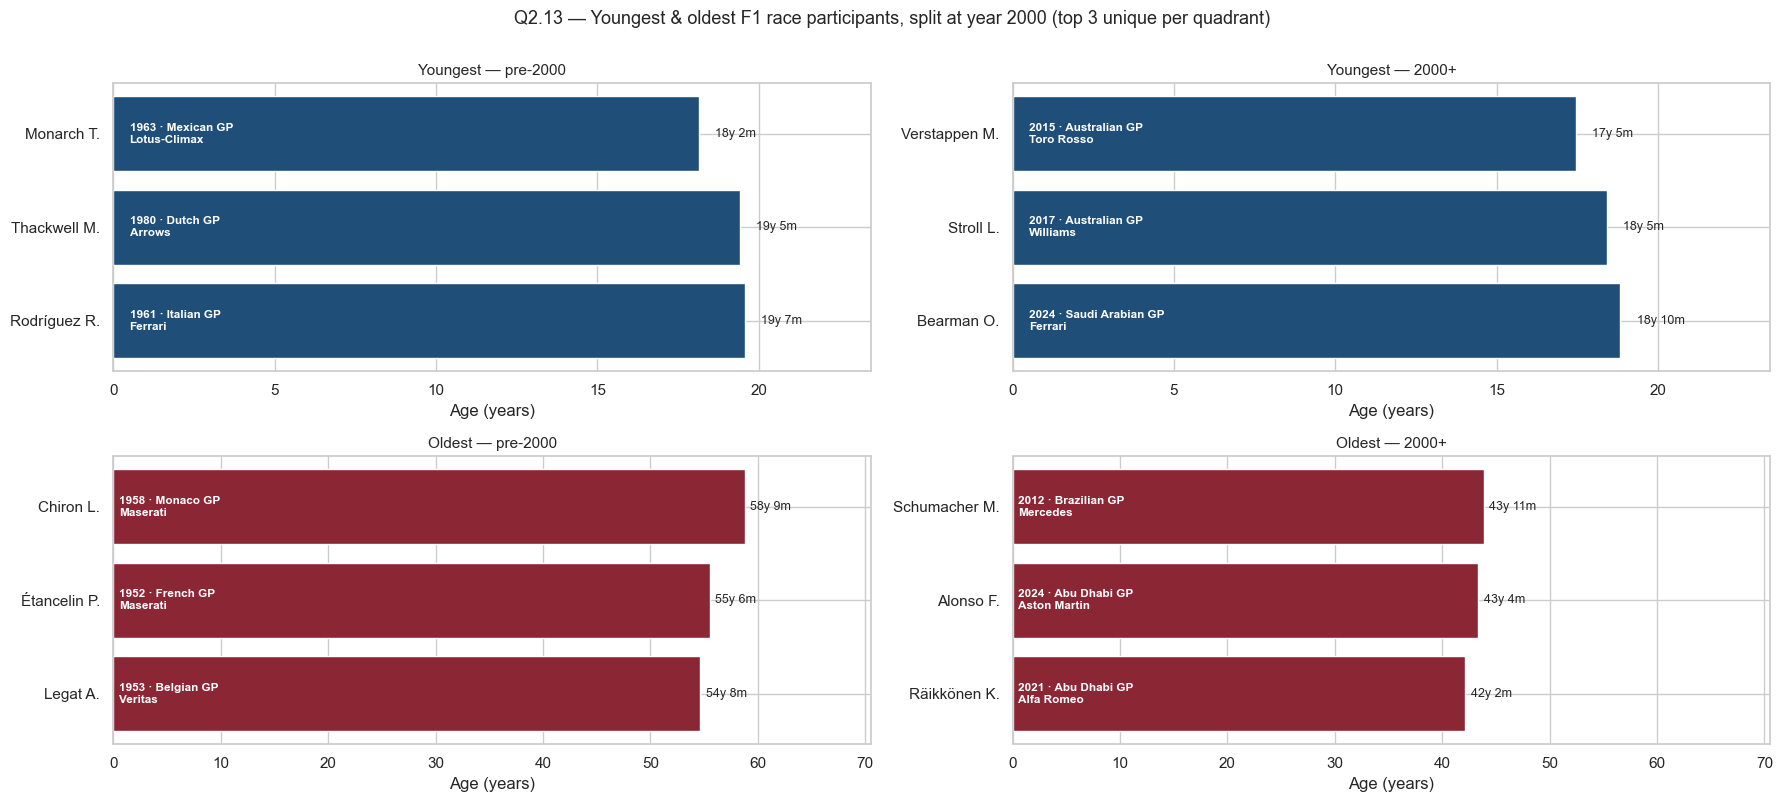


Youngest debut: pre-2000 = 18y 2m (Monarch T., 1963)  vs  2000+ = 17y 5m (Verstappen M., 2015)
Oldest start  : pre-2000 = 58y 9m (Chiron L., 1958)  vs  2000+ = 43y 11m (Schumacher M., 2012)


In [355]:
# Reuse the 'ages' frame built earlier — already has age, year, gp, team, driverId
# (Indy 500 races were dropped globally in the cleanup cell, so no extra filter needed.)
CUTOFF = 2000
pre  = ages[ages['year'] <  CUTOFF]
post = ages[ages['year'] >= CUTOFF]

def _top3(df, ascending):
    return df.sort_values('age', ascending=ascending).drop_duplicates('driverId').head(3)

young_pre,  old_pre  = _top3(pre,  True), _top3(pre,  False)
young_post, old_post = _top3(post, True), _top3(post, False)

for title, df in [('YOUNGEST pre-2000',  young_pre),
                  ('YOUNGEST 2000+',     young_post),
                  ('OLDEST pre-2000',    old_pre),
                  ('OLDEST 2000+',       old_post)]:
    print(f'\n{title} (top 3 unique):')
    print(df[['driver', 'age', 'year', 'gp', 'team']].to_string(index=False))


# Same single-panel helper used by the all-time version — one panel = one quadrant
def _draw_participant_panel(ax, df, panel_title, color, x_max):
    df = df.reset_index(drop=True)
    ax.barh(range(len(df)), df['age'], color=color)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df['driver'])

    for i, row in df.iterrows():
        ax.text(0.5, i,
                f'{int(row.year)} · {_short_gp(row.gp)[:22]}\n{row.team[:22]}',
                va='center', ha='left',
                fontsize=8.5, color='white', fontweight='bold')
        ax.text(row.age + 0.5, i, _format_age(row.age),
                va='center', fontsize=9)

    ax.set_title(panel_title, fontsize=11)
    ax.set_xlabel('Age (years)')
    ax.invert_yaxis()
    ax.set_xlim(0, x_max)


# Shared x-axis per row so pre-2000 vs 2000+ panels are visually comparable
young_x = max(young_pre['age'].max(), young_post['age'].max()) * 1.20
old_x   = max(old_pre['age'].max(),   old_post['age'].max())   * 1.20

NAVY, BURGUNDY = '#1F4E79', '#8B2635'

fig, axes = plt.subplots(2, 2, figsize=(18, 8))
_draw_participant_panel(axes[0, 0], young_pre,  'Youngest — pre-2000', NAVY,     young_x)
_draw_participant_panel(axes[0, 1], young_post, 'Youngest — 2000+',    NAVY,     young_x)
_draw_participant_panel(axes[1, 0], old_pre,    'Oldest — pre-2000',   BURGUNDY, old_x)
_draw_participant_panel(axes[1, 1], old_post,   'Oldest — 2000+',      BURGUNDY, old_x)

fig.suptitle('Q2.13 — Youngest & oldest F1 race participants, split at year 2000 (top 3 unique per quadrant)',
             fontsize=13, y=1.00)
fig.tight_layout()
show_and_save('2.13_youngest_oldest_by_era.png')

# Insight — how the extremes moved across the cutoff
print(f'\nYoungest debut: pre-2000 = {_format_age(young_pre.iloc[0].age)} '
      f'({young_pre.iloc[0].driver}, {int(young_pre.iloc[0].year)})  vs  '
      f'2000+ = {_format_age(young_post.iloc[0].age)} '
      f'({young_post.iloc[0].driver}, {int(young_post.iloc[0].year)})')
print(f'Oldest start  : pre-2000 = {_format_age(old_pre.iloc[0].age)} '
      f'({old_pre.iloc[0].driver}, {int(old_pre.iloc[0].year)})  vs  '
      f'2000+ = {_format_age(old_post.iloc[0].age)} '
      f'({old_post.iloc[0].driver}, {int(old_post.iloc[0].year)})')


**SQL equivalent**
```sql
-- Q2.13: Youngest race participant per era (swap MIN/ASC ↔ MAX/DESC for oldest)
WITH driver_age AS (
    SELECT
        r.driverId, ra.year, ra.name AS gp, c.name AS team,
        d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
        (julianday(ra.date) - julianday(d.dob)) / 365.25 AS age
    FROM   results       r
    JOIN   races         ra ON r.raceId        = ra.raceId
    JOIN   drivers       d  ON r.driverId      = d.driverId
    JOIN   constructors  c  ON r.constructorId = c.constructorId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
      AND  d.dob IS NOT NULL
      AND  ra.year <  2000     -- flip to `>= 2000` for the modern-era panel
)
SELECT *
FROM (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY driverId ORDER BY age) AS rn
    FROM   driver_age
) t
WHERE  rn = 1
ORDER  BY age           -- youngest first; reverse for oldest
LIMIT  3;
```


## Sidebar — Early F1 era (1950–1960)

Two diagnostic charts to understand what the early years actually looked like, and why we exclude them from the Q5 debut analysis below.

| Sidebar | Purpose |
|---|---|
| **A — Full 1950 season** | Print every race + the final championship standings of the very first F1 year |
| **B — Top 15 drivers, 1950–1960** | Wins, podiums, points, and active years for the era's most successful drivers |

The 1950–60 era was small — *6 real F1 races in 1950*, mostly European, plus the polluting Indy 500 that we already stripped. Many "drivers" appearing in the data only raced once or twice. Including them in a "best debut" analysis distorts the result.

In [356]:
# Sidebar A — full 1950 season

# Race calendar
races_1950 = (races[races['year'] == 1950]
              .sort_values('date')
              [['round', 'name', 'date']]
              .rename(columns={'name': 'gp'}))

# Last race of 1950 (so we can pull the FINAL championship standings)
last_race_1950 = (races[races['year'] == 1950]
                  .assign(date=lambda d: pd.to_datetime(d['date']))
                  .sort_values('date')
                  .iloc[-1])

final_1950 = (
    standings[standings['raceId'] == last_race_1950['raceId']]
    .merge(drivers[['driverId', 'forename', 'surname', 'nationality']],
           on='driverId')
)
final_1950['driver'] = final_1950['surname'] + ' ' + final_1950['forename'].str[0] + '.'
final_1950 = (final_1950
              .sort_values('position')
              [['position', 'driver', 'nationality', 'points', 'wins']])

print(f'1950 season — {len(races_1950)} championship rounds (Indy 500 excluded):')
print(races_1950.to_string(index=False))
print(f'\nFinal championship standings ({len(final_1950)} drivers):')
print(final_1950.to_string(index=False))

1950 season — 6 championship rounds (Indy 500 excluded):
 round                 gp       date
     1 British Grand Prix 1950-05-13
     2  Monaco Grand Prix 1950-05-21
     4   Swiss Grand Prix 1950-06-04
     5 Belgian Grand Prix 1950-06-18
     6  French Grand Prix 1950-07-02
     7 Italian Grand Prix 1950-09-03

Final championship standings (81 drivers):
 position            driver nationality  points  wins
        1         Farina N.     Italian    30.0     3
        2         Fangio J.   Argentine    27.0     3
        3        Fagioli L.     Italian    24.0     0
        4         Rosier L.      French    13.0     0
        5         Ascari A.     Italian    11.0     0
        6        Parsons J.    American     9.0     1
        7        Holland B.    American     6.0     0
        8           Bira P.        Thai     5.0     0
        9      Whitehead P.     British     4.0     0
       10         Chiron L.  Monegasque     4.0     0
       11        Parnell R.     British     4.

### Sidebar B — Top 15 drivers, 1950–1960 (by wins)

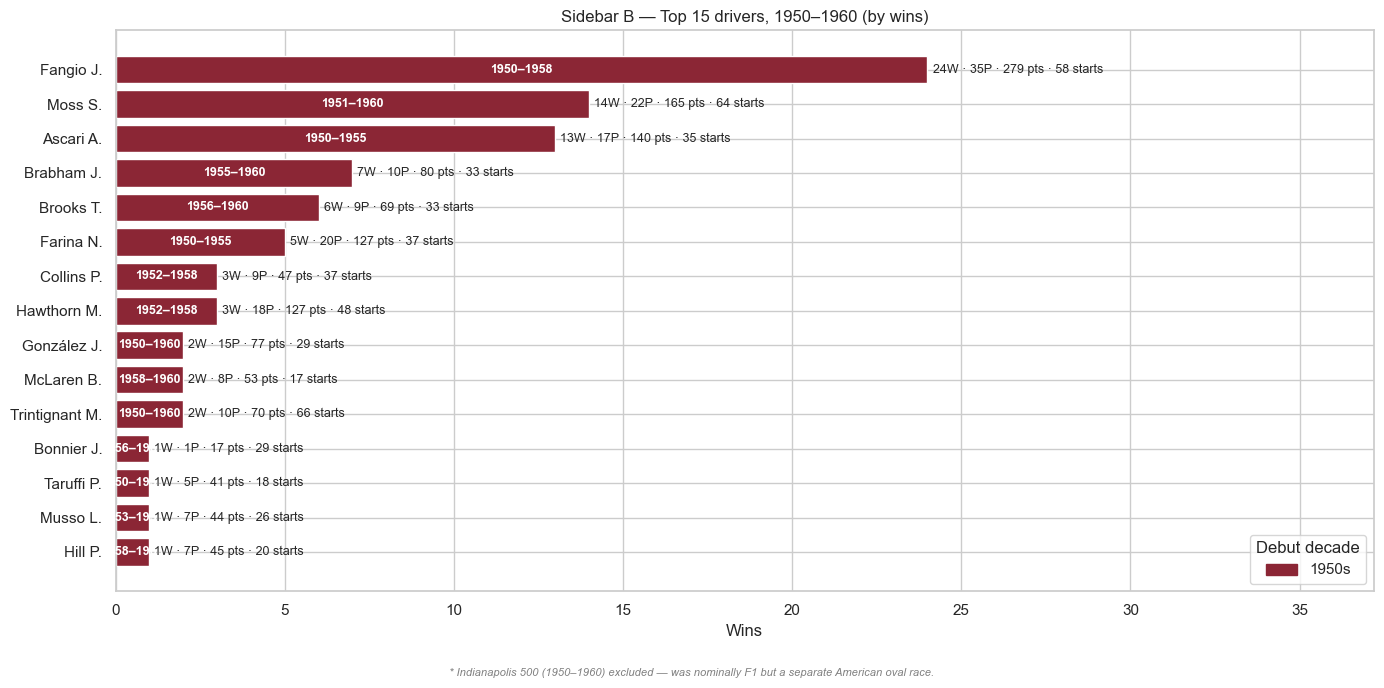

In [357]:
# Sidebar B — top 15 drivers in 1950-1960 by total wins

era_results = (
    results.merge(races[['raceId', 'year']], on='raceId')
    .query('1950 <= year <= 1960')
)

era_summary = (
    era_results.groupby('driverId')
    .agg(wins   =('positionOrder', lambda x: (x == 1).sum()),
         podiums=('positionOrder', lambda x: (x <= 3).sum()),
         races  =('raceId', 'count'),
         points =('points', 'sum'),
         first_year=('year', 'min'),
         last_year =('year', 'max'))
    .reset_index()
    .merge(drivers[['driverId', 'forename', 'surname', 'nationality']], on='driverId')
)

era_summary['driver'] = era_summary['surname'] + ' ' + era_summary['forename'].str[0] + '.'
era_summary['period'] = era_summary['first_year'].astype(str) + '–' + era_summary['last_year'].astype(str)
era_summary['decade'] = (era_summary['first_year'] // 10) * 10

top15_era = era_summary.nlargest(15, 'wins').sort_values('wins')  # asc → biggest at top after barh

# Chart — widened from 11→14 inches so the inline year ranges stop truncating
plt.figure(figsize=(14, 7))
bar_colors = [DECADE_COLORS[d] for d in top15_era['decade']]
plt.barh(range(len(top15_era)), top15_era['wins'], color=bar_colors)
plt.yticks(range(len(top15_era)), top15_era['driver'])

for i, row in enumerate(top15_era.itertuples()):
    bar_rgb = _hex_to_rgb(DECADE_COLORS[row.decade])
    text_color = 'white' if _luminance(bar_rgb) < 0.55 else '#1c1c1c'
    plt.text(row.wins / 2, i, row.period,
             va='center', ha='center',
             fontsize=9, fontweight='bold', color=text_color)
    plt.text(row.wins + 0.15, i,
             f'{row.wins}W · {row.podiums}P · {int(row.points)} pts · {row.races} starts',
             va='center', fontsize=9)

plt.title('Sidebar B — Top 15 drivers, 1950–1960 (by wins)')
plt.xlabel('Wins')
plt.ylabel('')
plt.xlim(0, top15_era['wins'].max() * 1.55)

used = sorted(top15_era['decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade',
           loc='lower right', frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.figtext(0.5, 0.02,
            '* Indianapolis 500 (1950–1960) excluded — was nominally F1 but a separate American oval race.',
            ha='center', va='bottom', fontsize=8, style='italic', color='gray')
show_and_save('sidebar_top15_1950_1960.png')

**SQL equivalent**
```sql
-- Sidebar B: Top 15 drivers in 1950–1960 by total wins (Indy 500 excluded)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    SUM(CASE WHEN r.positionOrder = 1  THEN 1 ELSE 0 END) AS wins,
    SUM(CASE WHEN r.positionOrder <= 3 THEN 1 ELSE 0 END) AS podiums,
    COUNT(*)                                              AS starts,
    SUM(r.points)                                         AS points,
    MIN(ra.year)                                          AS first_year,
    MAX(ra.year)                                          AS last_year
FROM   results r
JOIN   races   ra ON r.raceId   = ra.raceId
JOIN   drivers d  ON r.driverId = d.driverId
WHERE  ra.year BETWEEN 1950 AND 1960
  AND  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY r.driverId
ORDER  BY wins DESC
LIMIT  15;
```

## Q5 — Best F1 debuts, 1961 onwards *(two charts)*

We **exclude drivers who debuted in 1950–1960** (covered in the Sidebar above). The reasoning:
- Tiny early grids — many drivers raced once or twice.
- Era-specific scoring oddities.
- Indy 500 pollution (already stripped at the data level).

Two complementary angles for the modern era:

| Chart | Metric | Question answered |
|---|---|---|
| **Best debut RACE** | Finishing position in the very first race | Did they peak *immediately*? |
| **Best rookie CHAMPIONSHIP** | Final championship standing at the end of the debut season | How good was the *whole* rookie season? |

**Both charts:**
- Top 15 drivers, ordered by lowest position number (**P1 at top**).
- Tie-break: earlier year first.
- Bar length = inverse position rank — an **era-fair** visual encoding.
- Colour: debut decade.
- Dotted lines separate position groups.


In [358]:
# Step 1 — prep BOTH datasets (1961+ only) and build the helper
DEBUT_YEAR_MIN = 1961  # exclude 1950–1960 era

race_chronology = (
    results[['driverId', 'raceId', 'constructorId', 'positionOrder', 'points']]
    .merge(races_dt, on='raceId')
    .merge(drv_dt,   on='driverId')
    .merge(team_dt,  on='constructorId')
    .sort_values(['driverId', 'date'])
)
race_chronology['career_race'] = race_chronology.groupby('driverId').cumcount() + 1
race_chronology['driver']      = race_chronology['surname'] + ' ' + race_chronology['forename'].str[0] + '.'
race_chronology['decade']      = (race_chronology['year'] // 10) * 10

# Each driver's debut year, then keep only modern-era rookies
debut_years = (race_chronology[race_chronology['career_race'] == 1]
               [['driverId', 'year']]
               .rename(columns={'year': 'debut_year'}))
debut_years_modern = debut_years[debut_years['debut_year'] >= DEBUT_YEAR_MIN]


# ────────────────────────────────────────────────────────────────────
# A) BEST DEBUT RACE — finishing position in the very first race
# ────────────────────────────────────────────────────────────────────
best_debut_race = (race_chronology[race_chronology['career_race'] == 1]
                   .merge(debut_years_modern[['driverId']], on='driverId'))
top_race = best_debut_race.sort_values(['positionOrder', 'year']).head(15)


# ────────────────────────────────────────────────────────────────────
# B) BEST ROOKIE CHAMPIONSHIP — final standing in debut season
# ────────────────────────────────────────────────────────────────────
last_race_per_year = (races[['raceId', 'year', 'date']]
                      .assign(date=lambda d: pd.to_datetime(d['date']))
                      .sort_values('date')
                      .groupby('year').last()
                      .reset_index()[['year', 'raceId']])

final_standings = (
    standings.merge(last_race_per_year, on='raceId')
    [['driverId', 'year', 'position', 'points', 'wins']]
    .rename(columns={'position': 'champ_position', 'points': 'champ_points'})
)

# Each driver's main team in their debut year
rookie_team = (race_chronology
               .merge(debut_years_modern, on='driverId')
               .query('year == debut_year')
               .groupby('driverId').first()
               .reset_index()[['driverId', 'driver', 'team', 'decade']])

rookie_champ = (
    final_standings
    .merge(debut_years_modern, on='driverId')
    .query('year == debut_year')
    .merge(rookie_team, on='driverId')
    .dropna(subset=['champ_position'])
)

rookie_champ['positionOrder'] = rookie_champ['champ_position'].astype(int)
rookie_champ['points']        = rookie_champ['champ_points']
top_season = rookie_champ.sort_values(['positionOrder', 'year']).head(15)


print(f'Modern-era rookies (debut >= {DEBUT_YEAR_MIN}): {len(debut_years_modern):,}')
print(f'  who WON their debut race          : {(best_debut_race["positionOrder"] == 1).sum():,}')
print(f'  who were rookie CHAMPIONS         : {(rookie_champ["positionOrder"] == 1).sum():,}')
print()
print('TOP 15 best debut RACE:')
print(top_race[['driver', 'positionOrder', 'points', 'year', 'gp', 'team']].to_string(index=False))
print('\nTOP 15 best ROOKIE CHAMPIONSHIPS:')
print(top_season[['driver', 'positionOrder', 'points', 'wins', 'year', 'team']].to_string(index=False))


def plot_debut_ranking(df, title, filename, max_rank=11, show_gp=True,
                       outside_label_fn=None):
    """Top 15 by best position. Bar length = max_rank - positionOrder."""
    df = df.copy()
    df['inv_rank'] = max_rank - df['positionOrder']

    plt.figure(figsize=(13, 7))
    bar_colors = [DECADE_COLORS[d] for d in df['decade']]
    plt.barh(range(len(df)), df['inv_rank'], color=bar_colors)
    plt.yticks(range(len(df)), df['driver'])

    for i, row in enumerate(df.itertuples()):
        plt.text(-0.3, i, f'P{int(row.positionOrder)}',
                 va='center', ha='right',
                 fontsize=10, fontweight='bold', color='#444')

        bar_rgb = _hex_to_rgb(DECADE_COLORS[row.decade])
        text_color = 'white' if _luminance(bar_rgb) < 0.55 else '#1c1c1c'
        if show_gp:
            inside = f'{row.year} · {_short_gp(row.gp)}\n{row.team}'
        else:
            inside = f'{row.year}\n{row.team}'
        plt.text(row.inv_rank / 2, i, inside,
                 va='center', ha='center',
                 fontsize=8.5, fontweight='bold',
                 color=text_color)

        right_text = (outside_label_fn(row) if outside_label_fn
                      else f'{row.points:.0f} pts')
        plt.text(row.inv_rank + 0.3, i, right_text,
                 va='center', fontsize=9)

    last = df['positionOrder'].iloc[0]
    for i, pos in enumerate(df['positionOrder']):
        if pos != last:
            plt.axhline(y=i - 0.5, color='gray', linestyle=':',
                        alpha=0.5, linewidth=1)
            last = pos

    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel('')
    plt.ylabel('')
    plt.gca().set_xticks([])
    plt.xlim(-2, max_rank + 2)

    used = sorted(df['decade'].unique())
    handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_COLORS[d], label=f'{d}s')
               for d in used]
    plt.legend(handles=handles, title='Debut decade',
               loc='upper left', bbox_to_anchor=(1.02, 1.0),
               frameon=True)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.figtext(0.5, 0.02,
                f'* Drivers who debuted before {DEBUT_YEAR_MIN} excluded (see Sidebar).',
                ha='center', va='bottom',
                fontsize=8, style='italic', color='gray')
    show_and_save(filename)

Modern-era rookies (debut >= 1961): 507
  who WON their debut race          : 1
  who were rookie CHAMPIONS         : 0

TOP 15 best debut RACE:
       driver  positionOrder  points  year                       gp         team
  Baghetti G.              1     9.0  1961        French Grand Prix      Ferrari
Villeneuve J.              2     6.0  1996    Australian Grand Prix     Williams
 Magnussen K.              2    18.0  2014    Australian Grand Prix      McLaren
    Wisell R.              3     4.0  1970 United States Grand Prix   Team Lotus
   Donohue M.              3     4.0  1971      Canadian Grand Prix      McLaren
  Hamilton L.              3     6.0  2007    Australian Grand Prix      McLaren
    Elford V.              4     3.0  1968        French Grand Prix   Cooper-BRM
 Regazzoni C.              4     3.0  1970         Dutch Grand Prix      Ferrari
    Giunti I.              4     3.0  1970       Belgian Grand Prix      Ferrari
     Alesi J.              4     3.0  1989   

### Chart 2.14a — Top 15 best debut race finishes (1961+)

*Q5 angle — the "best-of" ranking. The literal Q2.14 (drivers who scored points on their debut race) is plotted further below as 2.14b.*


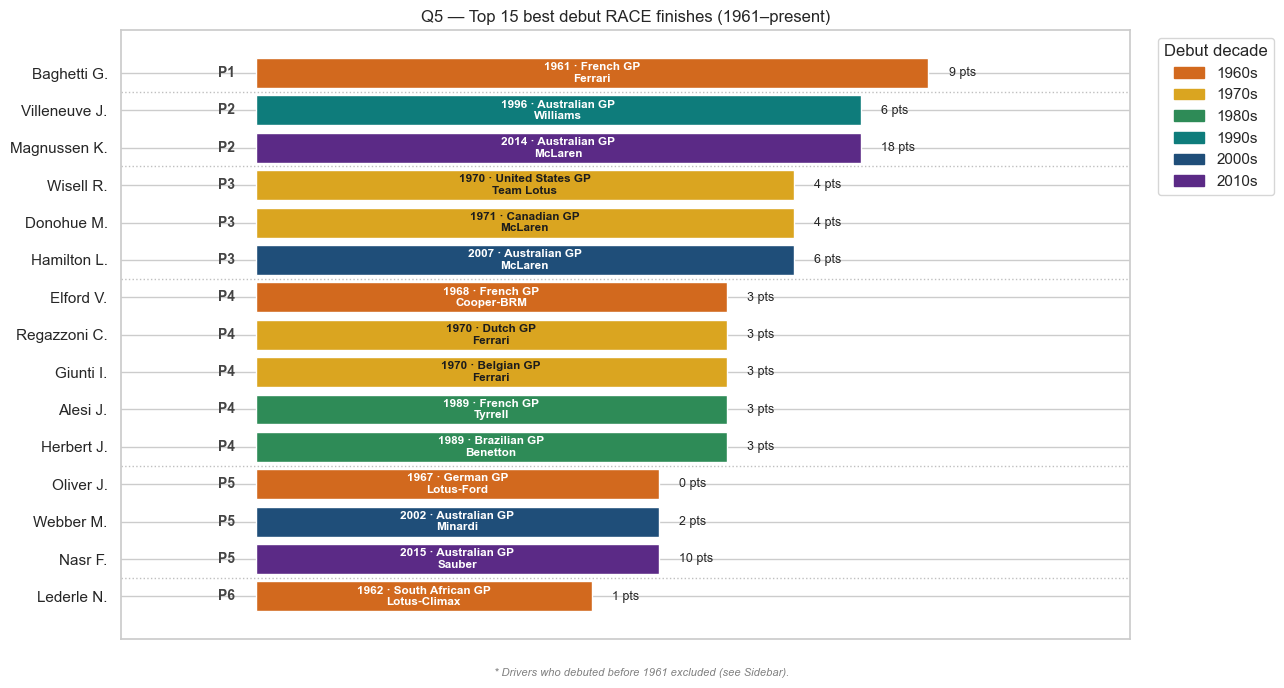

In [359]:
# Chart 1 — best debut RACE (1961+)
plot_debut_ranking(
    top_race,
    'Q5 — Top 15 best debut RACE finishes (1961–present)',
    '2.14_best_debut_race.png',
    max_rank=11,
    show_gp=True,
)

**SQL equivalent**
```sql
-- Q5: BEST DEBUT RACE — finishing position in driver's first ever F1 race (1961+)
WITH career_chronology AS (
    SELECT
        r.driverId, r.positionOrder, r.points,
        ra.year, ra.date, ra.name AS gp,
        c.name AS team,
        ROW_NUMBER() OVER (PARTITION BY r.driverId ORDER BY ra.date) AS career_race
    FROM   results       r
    JOIN   races         ra ON r.raceId        = ra.raceId
    JOIN   constructors  c  ON r.constructorId = c.constructorId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    cc.positionOrder, cc.points, cc.year, cc.gp, cc.team
FROM   career_chronology cc
JOIN   drivers d ON cc.driverId = d.driverId
WHERE  cc.career_race = 1
  AND  cc.year >= 1961                       -- exclude the 1950–1960 era
ORDER  BY cc.positionOrder, cc.year
LIMIT  15;
```

### Chart 2.15a — Top 15 best rookie championship finishes (1961+)

*Q5 angle — the "best-of" ranking. The literal Q2.15 (debut-season podium) is plotted further below as 2.15b.*


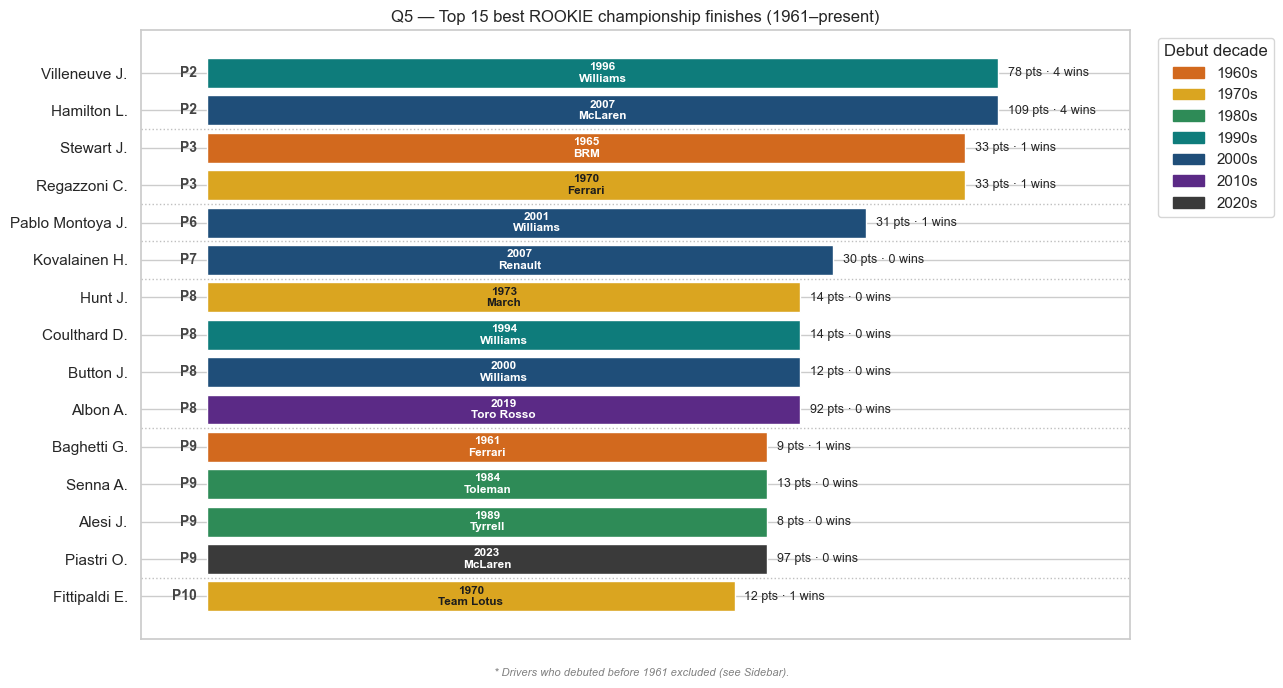

In [360]:
# Chart 2 — best ROOKIE CHAMPIONSHIP (final standing in debut season, 1961+)
plot_debut_ranking(
    top_season,
    'Q5 — Top 15 best ROOKIE championship finishes (1961–present)',
    '2.15_best_rookie_championship.png',
    max_rank=26,        # championship has up to ~25 positions
    show_gp=False,
    outside_label_fn=lambda r: f'{r.points:.0f} pts · {int(r.wins)} wins',
)

**SQL equivalent**
```sql
-- Q5: BEST ROOKIE CHAMPIONSHIP — final standing in the driver's debut SEASON (1961+)
WITH debut_year AS (
    SELECT r.driverId, MIN(ra.year) AS debut_yr
    FROM   results r
    JOIN   races   ra ON r.raceId = ra.raceId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
    GROUP  BY r.driverId
),
season_end AS (
    SELECT year, raceId
    FROM (
        SELECT year, raceId, date,
               ROW_NUMBER() OVER (PARTITION BY year ORDER BY date DESC) AS rn
        FROM   races
        WHERE  name NOT LIKE '%Indianapolis%'
    ) t
    WHERE rn = 1
)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    s.position AS final_position, s.points, s.wins, s.year
FROM   driver_standings s
JOIN   season_end       se ON s.raceId   = se.raceId
JOIN   debut_year       dy ON s.driverId = dy.driverId AND s.year = dy.debut_yr
JOIN   drivers          d  ON s.driverId = d.driverId
WHERE  dy.debut_yr >= 1961
ORDER  BY s.position, s.year
LIMIT  15;
```

## Q2.14 / Q2.15 / Q2.16 — Literal debut-season milestones

The Q5 section above answers a *related* family of questions — "best debut race finish" and "best rookie championship standing". The literal entries from `QuestionsF1.txt` are tighter:

- **Q2.14** — Drivers who **scored points** on their debut race (any position that paid out under that year's scoring system).
- **Q2.15** — Drivers who **scored a podium** in their debut **season** (anywhere in that calendar year, not just the first race).
- **Q2.16** — Drivers who **won a race** in their debut **season**.

These three are nested: every 2.16 driver is a 2.15 driver, and almost every 2.15 driver is a 2.14 driver. Together they form a tighter funnel than the "best-of" rankings above.

Indy 500 is already stripped at the data level. We do **not** apply the Q5 `1961+` filter here — every "first" matters for these questions, including the 1950s. Output is printed as tables (these are rare events; bar charts would be sparse).


In [361]:
# Reuse race_chronology built in the Q5 section (cell that defines DEBUT_YEAR_MIN).
# It already has career_race, year, gp, team, points, positionOrder per driver-race.

# Each driver's debut year (for "debut season" questions)
debut_year_all = (race_chronology[race_chronology['career_race'] == 1]
                  [['driverId', 'year']]
                  .rename(columns={'year': 'debut_year'}))

# All races a driver had during their debut season
debut_season_results = (race_chronology
                        .merge(debut_year_all, on='driverId')
                        .query('year == debut_year'))

print(f'All-time drivers (modern): {len(debut_year_all):,}')
print(f'Debut-season race rows   : {len(debut_season_results):,}')


All-time drivers (modern): 758
Debut-season race rows   : 3,832


### Chart 2.14b — Drivers who scored points on their debut race

Filter: `career_race == 1 AND points > 0`. The points threshold has changed over the years (top 6 from 1950, top 8 from 2003, top 10 from 2010) — using `points > 0` adapts to whatever scoring system was active that season.

Output: a full table plus a per-decade bar so the reader can see whether "points on debut" became easier (more positions paying out) or harder (deeper grid).


Drivers who scored points on their debut race: 60

        driver  year                       gp         team  positionOrder  points
     Sommer R.  1950        Monaco Grand Prix      Ferrari              4     3.0
    Bonetto F.  1950         Swiss Grand Prix     Maserati              5     2.0
    Fagioli L.  1950       British Grand Prix   Alfa Romeo              2     6.0
  Cabantous Y.  1950       British Grand Prix  Talbot-Lago              4     3.0
     Ascari A.  1950        Monaco Grand Prix      Ferrari              2     6.0
    Parnell R.  1950       British Grand Prix   Alfa Romeo              3     4.0
     Farina N.  1950       British Grand Prix   Alfa Romeo              1     9.0
   Serafini D.  1950       Italian Grand Prix      Ferrari              2     3.0
     Rosier L.  1950       British Grand Prix  Talbot-Lago              5     2.0
   Hawthorn M.  1952       Belgian Grand Prix       Cooper              4     3.0
    Wharton K.  1952         Swiss Grand Prix  

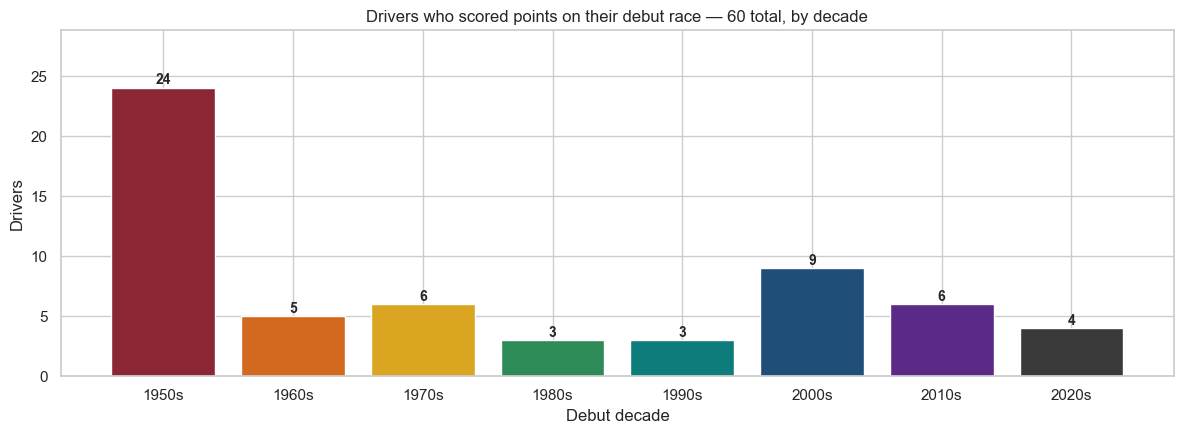

In [362]:
points_on_debut = (
    race_chronology[(race_chronology['career_race'] == 1) &
                    (race_chronology['points'] > 0)]
    [['driver', 'year', 'gp', 'team', 'positionOrder', 'points']]
    .sort_values('year')
)

print(f'Drivers who scored points on their debut race: {len(points_on_debut)}')
print()
print(points_on_debut.to_string(index=False))

# Decade bar — how often did this happen per decade?
points_on_debut['decade'] = (points_on_debut['year'] // 10) * 10
per_decade = (points_on_debut.groupby('decade').size()
              .reset_index(name='drivers')
              .sort_values('decade'))

plt.figure(figsize=(12, 4.5))
bar_colors = [DECADE_COLORS.get(d, '#999') for d in per_decade['decade']]
bars = plt.bar(per_decade['decade'].astype(str) + 's', per_decade['drivers'],
               color=bar_colors, edgecolor='white')

for bar, row in zip(bars, per_decade.itertuples()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3, str(row.drivers),
             ha='center', fontsize=10, fontweight='bold')

plt.title(f'Drivers who scored points on their debut race — {len(points_on_debut)} total, by decade')
plt.xlabel('Debut decade')
plt.ylabel('Drivers')
plt.ylim(0, per_decade['drivers'].max() * 1.20)
plt.tight_layout()
show_and_save('2.14_points_on_debut.png')


**SQL equivalent**
```sql
-- Q2.14: Drivers who scored points on their debut race
WITH career AS (
    SELECT
        r.driverId, r.points, r.positionOrder,
        ra.year, ra.name AS gp, c.name AS team,
        ROW_NUMBER() OVER (PARTITION BY r.driverId ORDER BY ra.date) AS career_race
    FROM   results       r
    JOIN   races         ra ON r.raceId        = ra.raceId
    JOIN   constructors  c  ON r.constructorId = c.constructorId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    cc.year, cc.gp, cc.team, cc.positionOrder, cc.points
FROM   career  cc
JOIN   drivers d ON cc.driverId = d.driverId
WHERE  cc.career_race = 1
  AND  cc.points > 0
ORDER  BY cc.year;
```


### Chart 2.15b — Drivers who scored a podium in their debut season

Filter: any race during the driver's debut year with `positionOrder <= 3`. This is much rarer than 2.14b — a debut-race podium is its own story (Hamilton 2007, Villeneuve 1996), but a podium *anywhere* in the debut season also includes drivers who built up to it later in the year.

Many drivers had multiple debut-season podiums (Hamilton had 9 in 2007). The table shows each driver's first such podium and a total count.


Drivers who scored a podium in their debut season: 50

          driver  year        team  first_pos  total
       Farina N.  1950  Alfa Romeo          1      3
       Ascari A.  1950     Ferrari          2      2
      Parnell R.  1950  Alfa Romeo          3      1
    Whitehead P.  1950     Ferrari          3      1
     Serafini D.  1950     Ferrari          2      1
       Rosier L.  1950 Talbot-Lago          3      2
       Fangio J.  1950  Alfa Romeo          1      3
      Fagioli L.  1950  Alfa Romeo          2      5
       Chiron L.  1950    Maserati          3      1
     Hawthorn M.  1952      Cooper          3      1
        Behra J.  1952     Gordini          3      1
        Kling K.  1954    Mercedes          2      1
  Castellotti E.  1955      Lancia          2      2
      Perdisa C.  1955    Maserati          3      1
   de Portago A.  1956     Ferrari          2      1
      Gregory M.  1957    Maserati          3      1
         Hill P.  1958     Ferrari          

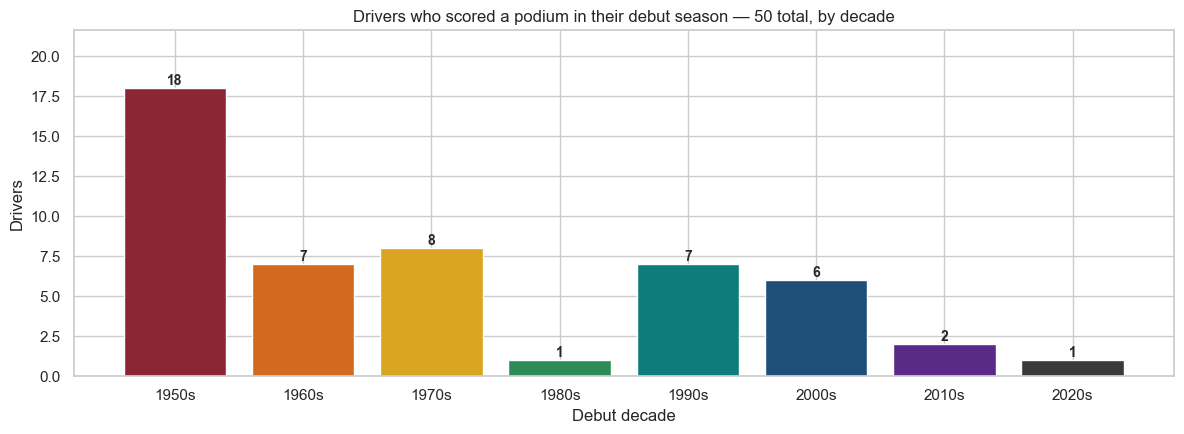

In [363]:
debut_podiums = (
    debut_season_results[debut_season_results['positionOrder'] <= 3]
    .sort_values(['driverId', 'date'])
)

# First debut-season podium per driver + total count
first_podium = (debut_podiums.groupby('driverId').first().reset_index()
                [['driverId', 'driver', 'year', 'gp', 'team', 'positionOrder']]
                .rename(columns={'positionOrder': 'first_podium_pos'}))
podium_counts = (debut_podiums.groupby('driverId').size()
                 .reset_index(name='podiums_in_debut_season'))

debut_podium_summary = (first_podium.merge(podium_counts, on='driverId')
                        .sort_values('year'))

print(f'Drivers who scored a podium in their debut season: {len(debut_podium_summary)}')
print()
print(debut_podium_summary
      [['driver', 'year', 'team', 'first_podium_pos', 'podiums_in_debut_season']]
      .rename(columns={'first_podium_pos': 'first_pos',
                       'podiums_in_debut_season': 'total'})
      .to_string(index=False))

# Bar — count per debut decade
debut_podium_summary['decade'] = (debut_podium_summary['year'] // 10) * 10
per_decade = (debut_podium_summary.groupby('decade').size()
              .reset_index(name='drivers')
              .sort_values('decade'))

plt.figure(figsize=(12, 4.5))
bar_colors = [DECADE_COLORS.get(d, '#999') for d in per_decade['decade']]
bars = plt.bar(per_decade['decade'].astype(str) + 's', per_decade['drivers'],
               color=bar_colors, edgecolor='white')

for bar, row in zip(bars, per_decade.itertuples()):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.2, str(row.drivers),
             ha='center', fontsize=10, fontweight='bold')

plt.title(f'Drivers who scored a podium in their debut season — {len(debut_podium_summary)} total, by decade')
plt.xlabel('Debut decade')
plt.ylabel('Drivers')
plt.ylim(0, per_decade['drivers'].max() * 1.20)
plt.tight_layout()
show_and_save('2.15_debut_season_podium.png')


**SQL equivalent**
```sql
-- Q2.15: Drivers who scored a podium during their debut SEASON
WITH debut_year AS (
    SELECT r.driverId, MIN(ra.year) AS debut_yr
    FROM   results r
    JOIN   races   ra ON r.raceId = ra.raceId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
    GROUP  BY r.driverId
)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    dy.debut_yr AS year,
    c.name AS team,
    MIN(r.positionOrder) AS first_podium_pos,
    COUNT(*) AS podiums_in_debut_season
FROM   results       r
JOIN   races         ra ON r.raceId        = ra.raceId
JOIN   debut_year    dy ON r.driverId      = dy.driverId AND ra.year = dy.debut_yr
JOIN   drivers       d  ON r.driverId      = d.driverId
JOIN   constructors  c  ON r.constructorId = c.constructorId
WHERE  ra.name NOT LIKE '%Indianapolis%'
  AND  r.positionOrder <= 3
GROUP  BY r.driverId
ORDER  BY year;
```


### Chart 2.16 — Drivers who won a race in their debut season

Filter: `positionOrder == 1` within the driver's debut year. Strictly nested inside 2.15 — every 2.16 driver appears in 2.15 too.

This is one of the rarest career milestones in F1 — fewer drivers have won a race in their debut season than have ever sat on pole. Output as a single table; bar/decade chart not useful when n is this small.


In [364]:
debut_wins = (
    debut_season_results[debut_season_results['positionOrder'] == 1]
    .sort_values(['driverId', 'date'])
)

# First debut-season win per driver + total wins
first_win = (debut_wins.groupby('driverId').first().reset_index()
             [['driverId', 'driver', 'year', 'gp', 'team']]
             .rename(columns={'gp': 'first_win_gp'}))
win_counts = (debut_wins.groupby('driverId').size()
              .reset_index(name='wins_in_debut_season'))

debut_win_summary = (first_win.merge(win_counts, on='driverId')
                     .sort_values('year'))

print(f'Drivers who won a race in their debut season: {len(debut_win_summary)}')
print()
print(debut_win_summary
      [['driver', 'year', 'team', 'first_win_gp', 'wins_in_debut_season']]
      .rename(columns={'first_win_gp': 'first_win',
                       'wins_in_debut_season': 'total'})
      .to_string(index=False))


Drivers who won a race in their debut season: 9

          driver  year       team                first_win  total
       Fangio J.  1950 Alfa Romeo        Monaco Grand Prix      3
       Farina N.  1950 Alfa Romeo       British Grand Prix      3
     Baghetti G.  1961    Ferrari        French Grand Prix      1
      Stewart J.  1965        BRM       Italian Grand Prix      1
   Fittipaldi E.  1970 Team Lotus United States Grand Prix      1
    Regazzoni C.  1970    Ferrari       Italian Grand Prix      1
   Villeneuve J.  1996   Williams      European Grand Prix      4
Pablo Montoya J.  2001   Williams       Italian Grand Prix      1
     Hamilton L.  2007    McLaren      Canadian Grand Prix      4


**SQL equivalent**
```sql
-- Q2.16: Drivers who won a race in their debut SEASON
WITH debut_year AS (
    SELECT r.driverId, MIN(ra.year) AS debut_yr
    FROM   results r
    JOIN   races   ra ON r.raceId = ra.raceId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
    GROUP  BY r.driverId
)
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.' AS driver,
    dy.debut_yr AS year,
    c.name AS team,
    COUNT(*) AS wins_in_debut_season
FROM   results       r
JOIN   races         ra ON r.raceId        = ra.raceId
JOIN   debut_year    dy ON r.driverId      = dy.driverId AND ra.year = dy.debut_yr
JOIN   drivers       d  ON r.driverId      = d.driverId
JOIN   constructors  c  ON r.constructorId = c.constructorId
WHERE  ra.name NOT LIKE '%Indianapolis%'
  AND  r.positionOrder = 1
GROUP  BY r.driverId
ORDER  BY year;
```


### Chart 2.17a — Drivers who share a last name

Group `drivers` by `surname`, keep groups with ≥ 2 drivers. For every
driver, derive their first and last race year (`results` × `races`).
Classify each surname as **Family** if any pair of drivers either
overlapped in time or has careers within 20 years of each other, otherwise
**Unrelated namesakes** (drivers separated by more than 20 years).

- **Tables:** `drivers`, `results`, `races`
- **Heuristic:** 20-year gap threshold (overlap OR within 20 yrs ⇒ Family)
- **Chart:** Horizontal bar, top 15 surnames, two-colour relationship split

   surname  n_drivers relationship                                                                                       drivers
    Taylor          5       Family Trevor (1959-1966), Henry (1959-1961), Mike (1959-1960), Dennis (1959-1959), John (1964-1966)
Fittipaldi          4       Family            Emerson (1970-1980), Wilson (1972-1975), Christian (1992-1994), Pietro (2020-2020)
   Brabham          3       Family                                         Jack (1955-1970), David (1990-1994), Gary (1990-1990)
      Hill          3       Family                                       Graham (1958-1975), Phil (1958-1966), Damon (1992-1999)
Schumacher          3       Family                                       Michael (1991-2012), Ralf (1997-2007), Mick (2021-2022)
   Stewart          3       Family                                        Jimmy (1953-1953), Ian (1953-1953), Jackie (1965-1973)
    Wilson          3       Family                                       Vic (1960-1966), Desiré 

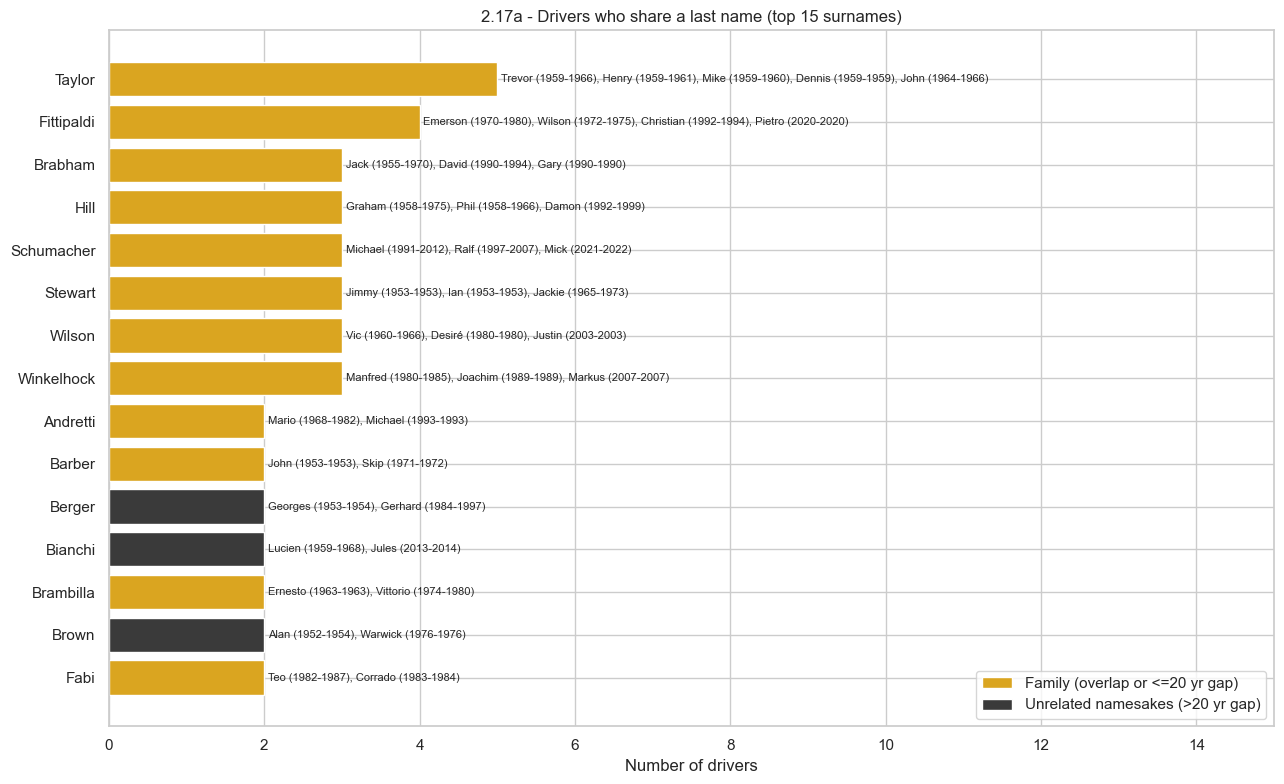

In [365]:
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#0077B6',
}

race_year = races[['raceId', 'year']]
driver_years = (
    results.merge(race_year, on='raceId')
           .groupby('driverId')['year']
           .agg(first_year='min', last_year='max')
           .reset_index()
)
driver_info = drivers.merge(driver_years, on='driverId', how='inner')

shared = driver_info.groupby('surname').filter(lambda g: len(g) >= 2)


def classify(group):
    spans = sorted(zip(group['first_year'], group['last_year']))
    for i in range(len(spans)):
        for j in range(i + 1, len(spans)):
            f1, l1 = spans[i]
            f2, l2 = spans[j]
            if max(f1, f2) <= min(l1, l2):
                return 'Family'
            gap = max(f2 - l1, f1 - l2)
            if gap <= 20:
                return 'Family'
    return 'Unrelated'


def describe(group):
    parts = []
    for r in group.sort_values('first_year').itertuples():
        parts.append(f"{r.forename} ({int(r.first_year)}-{int(r.last_year)})")
    return ', '.join(parts)


rows = []
for surname, group in shared.groupby('surname'):
    rows.append({
        'surname': surname,
        'n_drivers': len(group),
        'relationship': classify(group),
        'drivers': describe(group),
    })
summary = (
    pd.DataFrame(rows)
      .sort_values(['n_drivers', 'surname'], ascending=[False, True])
      .head(15)
      .reset_index(drop=True)
)
print(summary.to_string(index=False))

bar_colors = summary['relationship'].map(
    {'Family': ERA_COLORS[3], 'Unrelated': ERA_COLORS[8]}
)

fig, ax = plt.subplots(figsize=(13, 8))
y = range(len(summary))
bars = ax.barh(y, summary['n_drivers'], color=bar_colors)
ax.set_yticks(list(y))
ax.set_yticklabels(summary['surname'])
ax.invert_yaxis()
ax.set_xlabel('Number of drivers')
ax.set_title('2.17a - Drivers who share a last name (top 15 surnames)')

for bar, text in zip(bars, summary['drivers']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            text, va='center', fontsize=8)

ax.set_xlim(0, 15)

from matplotlib.patches import Patch
legend = [
    Patch(facecolor=ERA_COLORS[3], label='Family (overlap or <=20 yr gap)'),
    Patch(facecolor=ERA_COLORS[8], label='Unrelated namesakes (>20 yr gap)'),
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
show_and_save('2.17a_shared_surnames.png')

### Chart 2.17b — Most recent F1 families (top 15)

Chart 2.17a sorts surnames by **how many drivers share them**, with surname
alphabetical order as the tiebreak. Dozens of "exactly 2 drivers" surnames end
up tied — so modern father/son pairs like **Verstappen**, **Magnussen** and
**Rosberg** get pushed below the top-15 cutoff even though they're the most
recognisable F1 dynasties.

This view fixes that. Same data, but filtered to **Family** only (using 2.17a's
20-year-gap heuristic) and sorted by **the most recent driver's last race
year** — so the top of the chart is whichever family is still active or most
recently active.

- **Tables:** same as 2.17a (`drivers`, `results`, `races`)
- **Filter:** keep only Family-classified surnames
- **Sort key:** `MAX(last_year)` per surname, descending (then `n_drivers` desc as tiebreak)
- **Bar colour:** era of the most recent driver in that family

   surname  n_drivers  latest_year                                                                            drivers
 Magnussen          2         2024                                                 Jan (1995-1998), Kevin (2014-2024)
Verstappen          2         2024                                                   Jos (1994-2003), Max (2015-2024)
Schumacher          3         2022                            Michael (1991-2012), Ralf (1997-2007), Mick (2021-2022)
Fittipaldi          4         2020 Emerson (1970-1980), Wilson (1972-1975), Christian (1992-1994), Pietro (2020-2020)
   Rosberg          2         2016                                                 Keke (1978-1986), Nico (2006-2016)
     Senna          2         2012                                              Ayrton (1984-1994), Bruno (2010-2012)
  Nakajima          2         2009                                             Satoru (1987-1991), Kazuki (2007-2009)
Winkelhock          3         2007                      

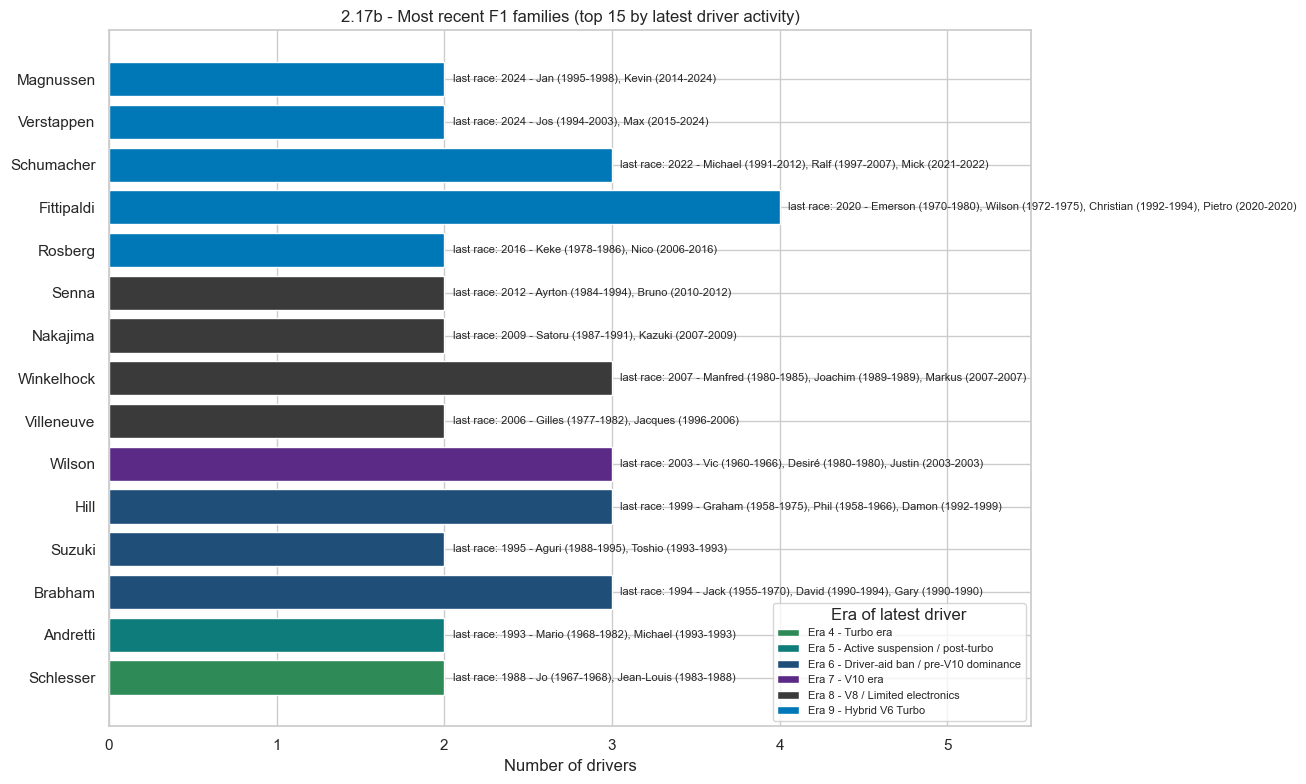

In [366]:
# 2.17b - Family surnames sorted by recency of activity.
# Reuses `shared`, `classify`, `describe`, `ERA_COLORS` from cell 2.17a above.

rows_recent = []
for surname, group in shared.groupby('surname'):
    if classify(group) != 'Family':
        continue
    rows_recent.append({
        'surname': surname,
        'n_drivers': len(group),
        'latest_year': int(group['last_year'].max()),
        'drivers': describe(group),
    })

summary_recent = (
    pd.DataFrame(rows_recent)
      .sort_values(['latest_year', 'n_drivers'], ascending=[False, False])
      .head(15)
      .reset_index(drop=True)
)
print(summary_recent.to_string(index=False))

# Bar colour = era of the most recent driver in each family
bar_colors = summary_recent['latest_year'].apply(
    lambda y: ERA_COLORS.get(year_to_era(y), '#888')
)

fig, ax = plt.subplots(figsize=(13, 8))
y_pos = range(len(summary_recent))
bars = ax.barh(y_pos, summary_recent['n_drivers'], color=bar_colors)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(summary_recent['surname'])
ax.invert_yaxis()
ax.set_xlabel('Number of drivers')
ax.set_title('2.17b - Most recent F1 families (top 15 by latest driver activity)')

for bar, year, text in zip(bars, summary_recent['latest_year'], summary_recent['drivers']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f'last race: {year} - {text}',
            va='center', fontsize=8)

ax.set_xlim(0, summary_recent['n_drivers'].max() + 1.5)

# Era legend - only eras present in the chart
from matplotlib.patches import Patch
eras_present = sorted({year_to_era(y) for y in summary_recent['latest_year']})
era_legend = [
    Patch(facecolor=ERA_COLORS[e],
          label=f"Era {e} - {eras_df.loc[eras_df['era_id'] == e, 'name_en'].iloc[0]}")
    for e in eras_present
]
ax.legend(handles=era_legend, loc='lower right',
          title='Era of latest driver', fontsize=8)
plt.tight_layout()
show_and_save('2.17b_recent_f1_families.png')

---
## Key insights from this notebook

What the driver-career analyses revealed:

1. **Of 861 F1 drivers, only ~14% (117) have ever won a race.** Reaching the top step is genuinely rare even at this level — the funnel from "all drivers" to "race winner" is a near-90% drop-off.

2. **The youngest race winner is younger than the youngest pole sitter.** Verstappen won at 18y 7m (Spain 2016); Vettel set the youngest pole at 21y 2m (Italy 2008). Wins can come from inheritance — strategy, safety cars, attrition; pole requires a single perfect lap on a competitive Saturday.

3. **Only one driver has won their debut race since 1961** — Giancarlo Baghetti (France 1961, Ferrari). In 60+ years of modern F1, debut wins are practically extinct.

4. **The two best rookie seasons are tied at P2 in the championship** — Villeneuve 1996 (Williams) and Hamilton 2007 (McLaren). Both lost the title to a *teammate* — by 19 points (Villeneuve) and a single point (Hamilton).

5. **The 1950 season ended with 81 drivers in the final standings** — but 66 of them scored zero points, mostly Indianapolis 500 specialists. After our Indy cleanup, only about six European drivers were genuinely competitive in that first championship year.

6. **"Never won, but raced forever" is a real F1 archetype.** The top of the "never won" chart includes Andrea de Cesaris (208 starts), Nico Hülkenberg (200+, still active) and Martin Brundle (158) — full careers without a single P1.

7. **The "never reached podium" list is dominated by 1990s–2000s drivers** (Trulli aside) — the era of paid-driver / midfield seats. Earlier drivers without podiums tended to have very short careers instead.
